<a href="https://colab.research.google.com/github/sahabi75/Football-Players-Performance-Prediction/blob/main/Striker%20Performance%20Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
import shap
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings("ignore")
import warnings
warnings.filterwarnings("ignore")



In [ ]:
db = pd.read_csv('/content/drive/MyDrive/Tittle Defense/Final Thesis/biometric_dataset.csv')
db.head()

,FullName,Age,Height(m),Position,Foot,CurrentClub,Total Distance(m) (per match),High-Intensity Distance(m),Sprint Distance(m),Sprint Count,Acceleration Count (≥3 m/s²),Deceleration Count (≤-3 m/s²),PlayerLoad AU (GPS-derived),Heart Rate Variability (ms),VO₂ Max (ml/kg/min),Muscle Strength (kg) (Leg Press),Fatigue Biomarkers-CK (U/L),Sleep Quality (percentage),Sleep Duration (h),Muscle Strength Asymmetry (%),Stride Length(m),Ground Contact Time (ms),Jump Height(cm) (Vertical),Landing Mechanics,ChangeOfDirectionAngle(degree),Stress Level (1-10),Mental Fatigue (Cognitive Tests),GPS PlayerLoad (AU),GPS Total Distance(m),ForcePlateJumpPower(W),ForcePlateSymmetry,RPE_Match,RPE_Training,RPE_Avg
0,Julio César Soler Barreto,20.0,1.75,Defender,Left,AFC Bournemouth,11150.0,975.0,375.0,21.5,60.0,55.0,500.0,NaN,60.0,200.0,225.0,85.0,8.75,5.0,2.50,200.0,52.5,88.0,52.5,4.0,1.00,500.0,11150.0,4500.0,90.0,8.0,5.25,6.62
1,Ilya Zabarnyi,22.0,1.89,Defender,Right,AFC Bournemouth,11500.0,1500.0,500.0,20.0,100.0,90.0,750.0,70.0,52.5,200.0,300.0,82.5,8.25,5.0,2.50,200.0,60.0,90.0,52.5,4.5,NaN,750.0,11500.0,4700.0,94.5,7.0,5.00,6.00
2,Justin Dean Kluivert,26.0,1.72,Midfielder,Both (ambidextrous),AFC Bournemouth,10500.0,1350.0,700.0,21.5,47.5,42.5,500.0,70.0,60.0,190.0,300.0,85.0,7.75,5.0,2.45,200.0,50.0,95.0,80.0,5.0,2.50,550.0,10500.0,4250.0,93.5,NaN,NaN,6.50
3,Kepa Arrizabalaga Revuelta,30.0,1.88,Goalkeeper,Right,AFC Bournemouth,5350.0,1000.0,300.0,10.0,20.0,15.0,400.0,70.0,50.0,200.0,300.0,85.0,8.00,5.0,NaN,250.0,55.0,90.0,67.5,6.0,5.50,400.0,5250.0,3250.0,93.5,NaN,5.00,5.00
4,William Jonathan Dennis,24.0,1.88,Goalkeeper,Right,AFC Bournemouth,4850.0,375.0,115.0,10.0,32.5,27.5,400.0,75.0,50.0,235.0,225.0,85.0,8.00,5.0,1.70,200.0,60.0,90.0,32.5,4.0,1.75,400.0,4850.0,4000.0,92.0,7.0,5.00,6.00


In [ ]:
db = db.rename(columns={"FullName": "PlayerName"})

In [ ]:
db.head()

,PlayerName,Age,Height(m),Position,Foot,CurrentClub,Total Distance(m) (per match),High-Intensity Distance(m),Sprint Distance(m),Sprint Count,Acceleration Count (≥3 m/s²),Deceleration Count (≤-3 m/s²),PlayerLoad AU (GPS-derived),Heart Rate Variability (ms),VO₂ Max (ml/kg/min),Muscle Strength (kg) (Leg Press),Fatigue Biomarkers-CK (U/L),Sleep Quality (percentage),Sleep Duration (h),Muscle Strength Asymmetry (%),Stride Length(m),Ground Contact Time (ms),Jump Height(cm) (Vertical),Landing Mechanics,ChangeOfDirectionAngle(degree),Stress Level (1-10),Mental Fatigue (Cognitive Tests),GPS PlayerLoad (AU),GPS Total Distance(m),ForcePlateJumpPower(W),ForcePlateSymmetry,RPE_Match,RPE_Training,RPE_Avg
0,Julio César Soler Barreto,20.0,1.75,Defender,Left,AFC Bournemouth,11150.0,975.0,375.0,21.5,60.0,55.0,500.0,NaN,60.0,200.0,225.0,85.0,8.75,5.0,2.50,200.0,52.5,88.0,52.5,4.0,1.00,500.0,11150.0,4500.0,90.0,8.0,5.25,6.62
1,Ilya Zabarnyi,22.0,1.89,Defender,Right,AFC Bournemouth,11500.0,1500.0,500.0,20.0,100.0,90.0,750.0,70.0,52.5,200.0,300.0,82.5,8.25,5.0,2.50,200.0,60.0,90.0,52.5,4.5,NaN,750.0,11500.0,4700.0,94.5,7.0,5.00,6.00
2,Justin Dean Kluivert,26.0,1.72,Midfielder,Both (ambidextrous),AFC Bournemouth,10500.0,1350.0,700.0,21.5,47.5,42.5,500.0,70.0,60.0,190.0,300.0,85.0,7.75,5.0,2.45,200.0,50.0,95.0,80.0,5.0,2.50,550.0,10500.0,4250.0,93.5,NaN,NaN,6.50
3,Kepa Arrizabalaga Revuelta,30.0,1.88,Goalkeeper,Right,AFC Bournemouth,5350.0,1000.0,300.0,10.0,20.0,15.0,400.0,70.0,50.0,200.0,300.0,85.0,8.00,5.0,NaN,250.0,55.0,90.0,67.5,6.0,5.50,400.0,5250.0,3250.0,93.5,NaN,5.00,5.00
4,William Jonathan Dennis,24.0,1.88,Goalkeeper,Right,AFC Bournemouth,4850.0,375.0,115.0,10.0,32.5,27.5,400.0,75.0,50.0,235.0,225.0,85.0,8.00,5.0,1.70,200.0,60.0,90.0,32.5,4.0,1.75,400.0,4850.0,4000.0,92.0,7.0,5.00,6.00


In [ ]:
di= pd.read_csv('/content/drive/MyDrive/Tittle Defense/Final Thesis/injury_dataset.csv')
di.head()

,PlayerName,PastEarlySeasonInjuries,PastMidSeasonInjuries,PastLateSeasonInjuries,PastContactInjuries,PastNonContactInjuries,PastBothInjuries,PastUnknownInjuries,PastNumberOfInjuries,PastTotalDaysOut,PastEarlySeasonDaysOut,PastMidSeasonDaysOut,PastLateSeasonDaysOut,PastEarlySeasonGamesMissed,PastMidSeasonGamesMissed,PastLateSeasonGamesMissed,PastTotalGamesMissed,EarlySeasonInjuries_2024_25,MidSeasonInjuries_2024_25,LateSeasonInjuries_2024_25,ContactInjuries_2024_25,NonContactInjuries_2024_25,BothInjuries_2024_25,UnknownInjuries_2024_25,NumberOfInjuries_2024_25,TotalDaysOut_2024_25,EarlySeasonDaysOut_2024_25,MidSeasonDaysOut_2024_25,LateSeasonDaysOut_2024_25,EarlySeasonGamesMissed_2024_25,MidSeasonGamesMissed_2024_25,LateSeasonGamesMissed_2024_25,TotalGamesMissed_2024_25,SeasonsPlayed_Total
0,Aaron Buchanan Hickey,3.0,5.0,1.0,1.0,1.0,3.0,4.0,9.0,726.0,573.0,87.0,66.0,87.0,16.0,12.0,115.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,89.0,0.0,89.0,0.0,0.0,13.0,0.0,13.0,7
1,Aaron Christopher Ramsdale,0.0,1.0,1.0,1.0,0.0,0.0,1.0,2.0,13.0,0.0,7.0,6.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,2.0,47.0,40.0,7.0,0.0,6.0,1.0,0.0,7.0,2
2,Aaron Wan-Bissaka,6.0,3.0,1.0,0.0,2.0,3.0,5.0,10.0,252.0,142.0,104.0,6.0,31.0,27.0,1.0,59.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
3,Aaron William Cresswell,4.0,7.0,2.0,3.0,7.0,4.0,1.0,15.0,241.0,44.0,45.0,58.0,6.0,12.0,8.0,43.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,11.0,0.0,0.0,11.0,0.0,0.0,2.0,2.0,5
4,Aarón Anselmino,0.0,0.0,1.0,0.0,1.0,0.0,1.0,2.0,109.0,0.0,0.0,51.0,0.0,0.0,11.0,20.0,1.0,1.0,0.0,0.0,2.0,0.0,0.0,2.0,120.0,38.0,82.0,0.0,7.0,17.0,0.0,24.0,3


In [ ]:
dp = pd.read_csv('/content/drive/MyDrive/Tittle Defense/Final Thesis/EPLs (1).csv')
dp.head()

,Full Name,Player ID,Year,Team,MP,MIN,GLS,AST,ASR,TOS,SOT,BCM,KEYP,BCC,SDR,APS,APS%,ALB,LBA%,ACR,CA%
0,Rasmus Winther Højlund,RWH,2024/25,Manchester United,52,3330.0,10.0,2.0,6.76,58.0,26,10.0,36.0,9.0,14.0,405.0,78.0,4,100.0,3,33.3
1,Rasmus Winther Højlund,RWH,2023/24,Manchester United,43,3085.0,16.0,2.0,6.90,57.0,30,16.0,38.0,1.0,28.0,414.0,75.5,10,83.3,2,20.0
2,Rasmus Winther Højlund,RWH,2022/23,Atalanta,41,2460.0,14.0,4.0,6.78,72.0,38,18.0,32.0,3.0,33.0,388.0,72.4,10,71.4,4,33.3
3,Rasmus Winther Højlund,RWH,2021/22,FC Copenhagen,33,1604.0,8.0,1.0,6.74,37.0,17,5.0,15.0,1.0,20.0,236.0,65.0,0,0.0,0,0.0
4,Rasmus Winther Højlund,RWH,2020/21,FC Copenhagen,4,164.0,0.0,0.0,6.40,7.0,1,2.0,1.0,0.0,1.0,33.0,78.6,0,0.0,0,0.0


In [ ]:
db.head()

,PlayerName,Age,Height(m),Position,Foot,CurrentClub,Total Distance(m) (per match),High-Intensity Distance(m),Sprint Distance(m),Sprint Count,Acceleration Count (≥3 m/s²),Deceleration Count (≤-3 m/s²),PlayerLoad AU (GPS-derived),Heart Rate Variability (ms),VO₂ Max (ml/kg/min),Muscle Strength (kg) (Leg Press),Fatigue Biomarkers-CK (U/L),Sleep Quality (percentage),Sleep Duration (h),Muscle Strength Asymmetry (%),Stride Length(m),Ground Contact Time (ms),Jump Height(cm) (Vertical),Landing Mechanics,ChangeOfDirectionAngle(degree),Stress Level (1-10),Mental Fatigue (Cognitive Tests),GPS PlayerLoad (AU),GPS Total Distance(m),ForcePlateJumpPower(W),ForcePlateSymmetry,RPE_Match,RPE_Training,RPE_Avg
0,Julio César Soler Barreto,20.0,1.75,Defender,Left,AFC Bournemouth,11150.0,975.0,375.0,21.5,60.0,55.0,500.0,NaN,60.0,200.0,225.0,85.0,8.75,5.0,2.50,200.0,52.5,88.0,52.5,4.0,1.00,500.0,11150.0,4500.0,90.0,8.0,5.25,6.62
1,Ilya Zabarnyi,22.0,1.89,Defender,Right,AFC Bournemouth,11500.0,1500.0,500.0,20.0,100.0,90.0,750.0,70.0,52.5,200.0,300.0,82.5,8.25,5.0,2.50,200.0,60.0,90.0,52.5,4.5,NaN,750.0,11500.0,4700.0,94.5,7.0,5.00,6.00
2,Justin Dean Kluivert,26.0,1.72,Midfielder,Both (ambidextrous),AFC Bournemouth,10500.0,1350.0,700.0,21.5,47.5,42.5,500.0,70.0,60.0,190.0,300.0,85.0,7.75,5.0,2.45,200.0,50.0,95.0,80.0,5.0,2.50,550.0,10500.0,4250.0,93.5,NaN,NaN,6.50
3,Kepa Arrizabalaga Revuelta,30.0,1.88,Goalkeeper,Right,AFC Bournemouth,5350.0,1000.0,300.0,10.0,20.0,15.0,400.0,70.0,50.0,200.0,300.0,85.0,8.00,5.0,NaN,250.0,55.0,90.0,67.5,6.0,5.50,400.0,5250.0,3250.0,93.5,NaN,5.00,5.00
4,William Jonathan Dennis,24.0,1.88,Goalkeeper,Right,AFC Bournemouth,4850.0,375.0,115.0,10.0,32.5,27.5,400.0,75.0,50.0,235.0,225.0,85.0,8.00,5.0,1.70,200.0,60.0,90.0,32.5,4.0,1.75,400.0,4850.0,4000.0,92.0,7.0,5.00,6.00


In [ ]:
dp.shape

(979, 21)

In [ ]:
de= pd.read_csv('/content/drive/MyDrive/Tittle Defense/Final Thesis/LaligaStriker (1).csv')
de.head()

,Full Name,Player ID,Year,Team,MP,MIN,GLS,AST,TOS,SOT,BCM,KEYP,BCC,SDR,APS,APS%,ALB,LBA%,ACR,CA%,ASR,CLS,YC,RC,ELTG,DRP,TACK,INT,BLS,ADW
0,Jorge de Frutos Sebastián,JDFS,25/26,Rayo Vallecano,14,918,5,3,21.0,9.0,4.0,18,4,12,162.0,78.3,5,62.5,2,10.5,7.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Jorge de Frutos Sebastián,JDFS,24/25,Rayo Vallecano,39,2662,8,3,56.0,21.0,10.0,33,8,32,449.0,74.1,9,33.3,15,21.4,6.77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Jorge de Frutos Sebastián,JDFS,23/24,Rayo Vallecano,40,1890,2,0,36.0,12.0,7.0,23,2,18,389.0,76.1,9,47.4,20,31.7,6.68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Jorge de Frutos Sebastián,JDFS,22/23,Levante UD,45,3483,5,6,73.0,20.0,8.0,54,13,66,590.0,71.9,19,42.2,25,18.0,6.71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Jorge de Frutos Sebastián,JDFS,21/22,Levante UD,25,1766,4,7,46.0,20.0,5.0,22,5,36,289.0,70.5,17,39.5,17,24.6,6.72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
de.shape

(1116, 30)

In [ ]:
cols_to_drop = ['CLS', 'YC', 'RC', 'ELTG', 'DRP', 'TACK', 'INT', 'BLS', 'ADW']

# Drop them safely (ignore errors if a column does not exist)
de = de.drop(columns=cols_to_drop, errors='ignore')

# View updated dataset
de.head()

,Full Name,Player ID,Year,Team,MP,MIN,GLS,AST,TOS,SOT,BCM,KEYP,BCC,SDR,APS,APS%,ALB,LBA%,ACR,CA%,ASR
0,Jorge de Frutos Sebastián,JDFS,25/26,Rayo Vallecano,14,918,5,3,21.0,9.0,4.0,18,4,12,162.0,78.3,5,62.5,2,10.5,7.28
1,Jorge de Frutos Sebastián,JDFS,24/25,Rayo Vallecano,39,2662,8,3,56.0,21.0,10.0,33,8,32,449.0,74.1,9,33.3,15,21.4,6.77
2,Jorge de Frutos Sebastián,JDFS,23/24,Rayo Vallecano,40,1890,2,0,36.0,12.0,7.0,23,2,18,389.0,76.1,9,47.4,20,31.7,6.68
3,Jorge de Frutos Sebastián,JDFS,22/23,Levante UD,45,3483,5,6,73.0,20.0,8.0,54,13,66,590.0,71.9,19,42.2,25,18.0,6.71
4,Jorge de Frutos Sebastián,JDFS,21/22,Levante UD,25,1766,4,7,46.0,20.0,5.0,22,5,36,289.0,70.5,17,39.5,17,24.6,6.72


In [ ]:
de = de[dp.columns]   # reorder to match dp


In [ ]:
de.head()

,Full Name,Player ID,Year,Team,MP,MIN,GLS,AST,ASR,TOS,SOT,BCM,KEYP,BCC,SDR,APS,APS%,ALB,LBA%,ACR,CA%
0,Jorge de Frutos Sebastián,JDFS,25/26,Rayo Vallecano,14,918,5,3,7.28,21.0,9.0,4.0,18,4,12,162.0,78.3,5,62.5,2,10.5
1,Jorge de Frutos Sebastián,JDFS,24/25,Rayo Vallecano,39,2662,8,3,6.77,56.0,21.0,10.0,33,8,32,449.0,74.1,9,33.3,15,21.4
2,Jorge de Frutos Sebastián,JDFS,23/24,Rayo Vallecano,40,1890,2,0,6.68,36.0,12.0,7.0,23,2,18,389.0,76.1,9,47.4,20,31.7
3,Jorge de Frutos Sebastián,JDFS,22/23,Levante UD,45,3483,5,6,6.71,73.0,20.0,8.0,54,13,66,590.0,71.9,19,42.2,25,18.0
4,Jorge de Frutos Sebastián,JDFS,21/22,Levante UD,25,1766,4,7,6.72,46.0,20.0,5.0,22,5,36,289.0,70.5,17,39.5,17,24.6


In [ ]:
de.shape

(1116, 21)

In [ ]:
merged_pf = pd.concat([dp, de], ignore_index=True)

In [ ]:
merged_pf.head()

,Full Name,Player ID,Year,Team,MP,MIN,GLS,AST,ASR,TOS,SOT,BCM,KEYP,BCC,SDR,APS,APS%,ALB,LBA%,ACR,CA%
0,Rasmus Winther Højlund,RWH,2024/25,Manchester United,52,3330.0,10.0,2.0,6.76,58.0,26,10.0,36.0,9.0,14.0,405.0,78.0,4,100.0,3,33.3
1,Rasmus Winther Højlund,RWH,2023/24,Manchester United,43,3085.0,16.0,2.0,6.90,57.0,30,16.0,38.0,1.0,28.0,414.0,75.5,10,83.3,2,20.0
2,Rasmus Winther Højlund,RWH,2022/23,Atalanta,41,2460.0,14.0,4.0,6.78,72.0,38,18.0,32.0,3.0,33.0,388.0,72.4,10,71.4,4,33.3
3,Rasmus Winther Højlund,RWH,2021/22,FC Copenhagen,33,1604.0,8.0,1.0,6.74,37.0,17,5.0,15.0,1.0,20.0,236.0,65.0,0,0.0,0,0.0
4,Rasmus Winther Højlund,RWH,2020/21,FC Copenhagen,4,164.0,0.0,0.0,6.40,7.0,1,2.0,1.0,0.0,1.0,33.0,78.6,0,0.0,0,0.0


In [ ]:
merged_pf.shape

(2095, 21)

In [ ]:
merged_pf.to_csv('/content/merged_players.csv', index=False)


In [ ]:
import pandas as pd
import numpy as np

# -------------------------------------------------------
# 1) Load your merged season-by-season dataset
# -------------------------------------------------------
merged_pf = pd.read_csv('/content/merged_players.csv')

# Ensure Year is string
merged_pf["Year"] = merged_pf["Year"].astype(str)

# Stats used for totals & per-match averages
stat_cols = ["MIN","GLS","AST","ASR","TOS","SOT","BCM","KEYP","BCC",
             "SDR","APS","APS%","ALB","LBA%","ACR","CA%"]

# Convert to numeric
for col in ["MP"] + stat_cols:
    merged_pf[col] = pd.to_numeric(merged_pf[col], errors="coerce")


# -------------------------------------------------------
# 2) BEFORE 2024/25
# -------------------------------------------------------
before_df = merged_pf[merged_pf["Year"] != "2024/25"]

before_agg = before_df.groupby("Full Name").agg(
    Total_MP_before=("MP", "sum"),
    **{f"Total_{c}_before": (c, "sum") for c in stat_cols}
).reset_index()

# Per-match averages BEFORE 24/25
for c in stat_cols:
    before_agg[f"Avg_{c}_per_match_before"] = (
        before_agg[f"Total_{c}_before"] /
        before_agg["Total_MP_before"].replace(0, np.nan)
    )

# Keep useful columns only
before_agg = before_agg[
    ["Full Name", "Total_MP_before"] +
    [f"Avg_{c}_per_match_before" for c in stat_cols]
]


# -------------------------------------------------------
# 3) 2024/25 SEASON
# -------------------------------------------------------
season_df = merged_pf[merged_pf["Year"] == "2024/25"]

season_agg = season_df.groupby("Full Name").agg(
    Total_MP_2425=("MP", "sum"),
    **{f"Total_{c}_2425": (c, "sum") for c in stat_cols}
).reset_index()

# Per-match averages FOR 24/25
for c in stat_cols:
    season_agg[f"Avg_{c}_per_match_2425"] = (
        season_agg[f"Total_{c}_2425"] /
        season_agg["Total_MP_2425"].replace(0, np.nan)
    )

season_agg = season_agg[
    ["Full Name", "Total_MP_2425"] +
    [f"Avg_{c}_per_match_2425" for c in stat_cols]
]


# -------------------------------------------------------
# 4) MERGE INTO FINAL ONE-ROW-PER-PLAYER DATASET
# -------------------------------------------------------
final_df = pd.merge(before_agg, season_agg, on="Full Name", how="outer")


# -------------------------------------------------------
# 5) SAVE AS PROPER CSV FILE
# -------------------------------------------------------
final_df.to_csv('/content/players_aggregated_before_and_2425.csv', index=False)

print("CSV file saved successfully at:")
print("/content/players_aggregated_before_and_2425.csv")

# Show preview
final_df.head()


CSV file saved successfully at:
/content/players_aggregated_before_and_2425.csv


,Full Name,Total_MP_before,Avg_MIN_per_match_before,Avg_GLS_per_match_before,Avg_AST_per_match_before,Avg_ASR_per_match_before,Avg_TOS_per_match_before,Avg_SOT_per_match_before,Avg_BCM_per_match_before,Avg_KEYP_per_match_before,Avg_BCC_per_match_before,Avg_SDR_per_match_before,Avg_APS_per_match_before,Avg_APS%_per_match_before,Avg_ALB_per_match_before,Avg_LBA%_per_match_before,Avg_ACR_per_match_before,Avg_CA%_per_match_before,Total_MP_2425,Avg_MIN_per_match_2425,Avg_GLS_per_match_2425,Avg_AST_per_match_2425,Avg_ASR_per_match_2425,Avg_TOS_per_match_2425,Avg_SOT_per_match_2425,Avg_BCM_per_match_2425,Avg_KEYP_per_match_2425,Avg_BCC_per_match_2425,Avg_SDR_per_match_2425,Avg_APS_per_match_2425,Avg_APS%_per_match_2425,Avg_ALB_per_match_2425,Avg_LBA%_per_match_2425,Avg_ACR_per_match_2425,Avg_CA%_per_match_2425
0,Abdessamad Ezzalzouli,143,53.874126,0.167832,0.048951,0.243427,0.000000,0.000000,0.000000,0.636364,0.370629,1.769231,14.125874,2.688811,0.335664,2.364336,0.223776,0.406294,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Abdón Prats Bastidas,254,36.011811,0.185039,0.055118,0.265433,1.082677,0.472441,0.145669,0.503937,0.110236,0.204724,4.956693,2.539370,0.240157,2.153543,0.133858,0.326378,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Abel Ruiz Ortega,224,55.767857,0.165179,0.066964,0.266116,1.102679,0.437500,0.241071,0.665179,0.089286,0.437500,10.281250,3.153571,0.200893,1.983036,0.062500,0.443304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Adama Traoré Diarra,301,53.857143,0.069767,0.109635,0.231362,0.890365,0.272425,0.049834,0.936877,0.142857,3.870432,10.541528,2.264452,0.312292,1.603322,0.780731,0.676080,41.0,48.536585,0.04878,0.195122,0.166585,0.95122,0.292683,0.170732,1.097561,0.292683,1.243902,11.0,1.997561,0.268293,1.412195,0.756098,0.668293
4,Adrián Embarba Blázquez,371,68.460916,0.150943,0.183288,0.205849,1.927224,0.665768,0.107817,1.493261,0.264151,1.301887,15.026954,2.183558,0.800539,1.355526,1.390836,0.676550,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
final_df.shape

(275, 35)

In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Full Name                  275 non-null    object 
 1   Total_MP_before            275 non-null    int64  
 2   Avg_MIN_per_match_before   275 non-null    float64
 3   Avg_GLS_per_match_before   275 non-null    float64
 4   Avg_AST_per_match_before   275 non-null    float64
 5   Avg_ASR_per_match_before   275 non-null    float64
 6   Avg_TOS_per_match_before   275 non-null    float64
 7   Avg_SOT_per_match_before   275 non-null    float64
 8   Avg_BCM_per_match_before   275 non-null    float64
 9   Avg_KEYP_per_match_before  275 non-null    float64
 10  Avg_BCC_per_match_before   275 non-null    float64
 11  Avg_SDR_per_match_before   275 non-null    float64
 12  Avg_APS_per_match_before   275 non-null    float64
 13  Avg_APS%_per_match_before  275 non-null    float64

In [ ]:
import pandas as pd

# Work directly on final_df
df = final_df.copy()

# Create new feature
df["StrikerPerformanceIndex"] = (
    0.6 * df["Avg_GLS_per_match_2425"].fillna(0) +
    0.2 * df["Avg_SOT_per_match_2425"].fillna(0) +
    0.2 * df["Avg_KEYP_per_match_2425"].fillna(0)
)

# Preview
df.head()


,Full Name,Total_MP_before,Avg_MIN_per_match_before,Avg_GLS_per_match_before,Avg_AST_per_match_before,Avg_ASR_per_match_before,Avg_TOS_per_match_before,Avg_SOT_per_match_before,Avg_BCM_per_match_before,Avg_KEYP_per_match_before,Avg_BCC_per_match_before,Avg_SDR_per_match_before,Avg_APS_per_match_before,Avg_APS%_per_match_before,Avg_ALB_per_match_before,Avg_LBA%_per_match_before,Avg_ACR_per_match_before,Avg_CA%_per_match_before,Total_MP_2425,Avg_MIN_per_match_2425,Avg_GLS_per_match_2425,Avg_AST_per_match_2425,Avg_ASR_per_match_2425,Avg_TOS_per_match_2425,Avg_SOT_per_match_2425,Avg_BCM_per_match_2425,Avg_KEYP_per_match_2425,Avg_BCC_per_match_2425,Avg_SDR_per_match_2425,Avg_APS_per_match_2425,Avg_APS%_per_match_2425,Avg_ALB_per_match_2425,Avg_LBA%_per_match_2425,Avg_ACR_per_match_2425,Avg_CA%_per_match_2425,StrikerPerformanceIndex
0,Abdessamad Ezzalzouli,143,53.874126,0.167832,0.048951,0.243427,0.000000,0.000000,0.000000,0.636364,0.370629,1.769231,14.125874,2.688811,0.335664,2.364336,0.223776,0.406294,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
1,Abdón Prats Bastidas,254,36.011811,0.185039,0.055118,0.265433,1.082677,0.472441,0.145669,0.503937,0.110236,0.204724,4.956693,2.539370,0.240157,2.153543,0.133858,0.326378,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
2,Abel Ruiz Ortega,224,55.767857,0.165179,0.066964,0.266116,1.102679,0.437500,0.241071,0.665179,0.089286,0.437500,10.281250,3.153571,0.200893,1.983036,0.062500,0.443304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
3,Adama Traoré Diarra,301,53.857143,0.069767,0.109635,0.231362,0.890365,0.272425,0.049834,0.936877,0.142857,3.870432,10.541528,2.264452,0.312292,1.603322,0.780731,0.676080,41.0,48.536585,0.04878,0.195122,0.166585,0.95122,0.292683,0.170732,1.097561,0.292683,1.243902,11.0,1.997561,0.268293,1.412195,0.756098,0.668293,0.307317
4,Adrián Embarba Blázquez,371,68.460916,0.150943,0.183288,0.205849,1.927224,0.665768,0.107817,1.493261,0.264151,1.301887,15.026954,2.183558,0.800539,1.355526,1.390836,0.676550,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 36 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Full Name                  275 non-null    object 
 1   Total_MP_before            275 non-null    int64  
 2   Avg_MIN_per_match_before   275 non-null    float64
 3   Avg_GLS_per_match_before   275 non-null    float64
 4   Avg_AST_per_match_before   275 non-null    float64
 5   Avg_ASR_per_match_before   275 non-null    float64
 6   Avg_TOS_per_match_before   275 non-null    float64
 7   Avg_SOT_per_match_before   275 non-null    float64
 8   Avg_BCM_per_match_before   275 non-null    float64
 9   Avg_KEYP_per_match_before  275 non-null    float64
 10  Avg_BCC_per_match_before   275 non-null    float64
 11  Avg_SDR_per_match_before   275 non-null    float64
 12  Avg_APS_per_match_before   275 non-null    float64
 13  Avg_APS%_per_match_before  275 non-null    float64

In [ ]:
cols_to_remove = [
    "Total_MP_2425",
    "Avg_MIN_per_match_2425",
    "Avg_GLS_per_match_2425",
    "Avg_AST_per_match_2425",
    "Avg_ASR_per_match_2425",
    "Avg_TOS_per_match_2425",
    "Avg_SOT_per_match_2425",
    "Avg_BCM_per_match_2425",
    "Avg_KEYP_per_match_2425",
    "Avg_BCC_per_match_2425",
    "Avg_SDR_per_match_2425",
    "Avg_APS_per_match_2425",
    "Avg_APS%_per_match_2425",
    "Avg_ALB_per_match_2425",
    "Avg_LBA%_per_match_2425",
    "Avg_ACR_per_match_2425",
    "Avg_CA%_per_match_2425",
]

df = df.drop(columns=cols_to_remove, errors="ignore")

df.head()


,Full Name,Total_MP_before,Avg_MIN_per_match_before,Avg_GLS_per_match_before,Avg_AST_per_match_before,Avg_ASR_per_match_before,Avg_TOS_per_match_before,Avg_SOT_per_match_before,Avg_BCM_per_match_before,Avg_KEYP_per_match_before,Avg_BCC_per_match_before,Avg_SDR_per_match_before,Avg_APS_per_match_before,Avg_APS%_per_match_before,Avg_ALB_per_match_before,Avg_LBA%_per_match_before,Avg_ACR_per_match_before,Avg_CA%_per_match_before,StrikerPerformanceIndex
0,Abdessamad Ezzalzouli,143,53.874126,0.167832,0.048951,0.243427,0.000000,0.000000,0.000000,0.636364,0.370629,1.769231,14.125874,2.688811,0.335664,2.364336,0.223776,0.406294,0.000000
1,Abdón Prats Bastidas,254,36.011811,0.185039,0.055118,0.265433,1.082677,0.472441,0.145669,0.503937,0.110236,0.204724,4.956693,2.539370,0.240157,2.153543,0.133858,0.326378,0.000000
2,Abel Ruiz Ortega,224,55.767857,0.165179,0.066964,0.266116,1.102679,0.437500,0.241071,0.665179,0.089286,0.437500,10.281250,3.153571,0.200893,1.983036,0.062500,0.443304,0.000000
3,Adama Traoré Diarra,301,53.857143,0.069767,0.109635,0.231362,0.890365,0.272425,0.049834,0.936877,0.142857,3.870432,10.541528,2.264452,0.312292,1.603322,0.780731,0.676080,0.307317
4,Adrián Embarba Blázquez,371,68.460916,0.150943,0.183288,0.205849,1.927224,0.665768,0.107817,1.493261,0.264151,1.301887,15.026954,2.183558,0.800539,1.355526,1.390836,0.676550,0.000000


In [ ]:
df.isnull().sum()


,0
Full Name,0
Total_MP_before,0
Avg_MIN_per_match_before,0
Avg_GLS_per_match_before,0
Avg_AST_per_match_before,0
Avg_ASR_per_match_before,0
Avg_TOS_per_match_before,0
Avg_SOT_per_match_before,0
Avg_BCM_per_match_before,0
Avg_KEYP_per_match_before,0


In [ ]:
rename_dict = {
    "Full Name": "Player Name",
    "Total_MP_before": "Total Matches Played (Before 2024/25)",
    "Avg_MIN_per_match_before": "Average Minutes per Match (Before 2024/25)",
    "Avg_GLS_per_match_before": "Average Goals per Match (Before 2024/25)",
    "Avg_AST_per_match_before": "Average Assists per Match (Before 2024/25)",
    "Avg_ASR_per_match_before": "Average Sofascore Rating (Before 2024/25)",
    "Avg_TOS_per_match_before": "Average Total Shots (Before 2024/25)",
    "Avg_SOT_per_match_before": "Average Shots on Target (Before 2024/25)",
    "Avg_BCM_per_match_before": "Average Big Chances Missed (Before 2024/25)",
    "Avg_KEYP_per_match_before": "Average Key Passes (Before 2024/25)",
    "Avg_BCC_per_match_before": "Average Big Chances Created (Before 2024/25)",
    "Avg_SDR_per_match_before": "Average Successful Dribbles (Before 2024/25)",
    "Avg_APS_per_match_before": "Average Accurate Passes (Before 2024/25)",
    "Avg_APS%_per_match_before": "Passing Accuracy (%) (Before 2024/25)",
    "Avg_ALB_per_match_before": "Average Accurate Long Balls (Before 2024/25)",
    "Avg_LBA%_per_match_before": "Long Ball Accuracy (%) (Before 2024/25)",
    "Avg_ACR_per_match_before": "Average Accurate Crosses (Before 2024/25)",
    "Avg_CA%_per_match_before": "Crossing Accuracy (%) (Before 2024/25)",
    "StrikerPerformanceIndex": "Striker Performance Index"
}

df = df.rename(columns=rename_dict)
df.to_csv('/content/stricker.csv', index=False)
df.head()


,Player Name,Total Matches Played (Before 2024/25),Average Minutes per Match (Before 2024/25),Average Goals per Match (Before 2024/25),Average Assists per Match (Before 2024/25),Average Sofascore Rating (Before 2024/25),Average Total Shots (Before 2024/25),Average Shots on Target (Before 2024/25),Average Big Chances Missed (Before 2024/25),Average Key Passes (Before 2024/25),Average Big Chances Created (Before 2024/25),Average Successful Dribbles (Before 2024/25),Average Accurate Passes (Before 2024/25),Passing Accuracy (%) (Before 2024/25),Average Accurate Long Balls (Before 2024/25),Long Ball Accuracy (%) (Before 2024/25),Average Accurate Crosses (Before 2024/25),Crossing Accuracy (%) (Before 2024/25),Striker Performance Index
0,Abdessamad Ezzalzouli,143,53.874126,0.167832,0.048951,0.243427,0.000000,0.000000,0.000000,0.636364,0.370629,1.769231,14.125874,2.688811,0.335664,2.364336,0.223776,0.406294,0.000000
1,Abdón Prats Bastidas,254,36.011811,0.185039,0.055118,0.265433,1.082677,0.472441,0.145669,0.503937,0.110236,0.204724,4.956693,2.539370,0.240157,2.153543,0.133858,0.326378,0.000000
2,Abel Ruiz Ortega,224,55.767857,0.165179,0.066964,0.266116,1.102679,0.437500,0.241071,0.665179,0.089286,0.437500,10.281250,3.153571,0.200893,1.983036,0.062500,0.443304,0.000000
3,Adama Traoré Diarra,301,53.857143,0.069767,0.109635,0.231362,0.890365,0.272425,0.049834,0.936877,0.142857,3.870432,10.541528,2.264452,0.312292,1.603322,0.780731,0.676080,0.307317
4,Adrián Embarba Blázquez,371,68.460916,0.150943,0.183288,0.205849,1.927224,0.665768,0.107817,1.493261,0.264151,1.301887,15.026954,2.183558,0.800539,1.355526,1.390836,0.676550,0.000000


In [ ]:
df = df.rename(columns={"Player Name": "PlayerName"})

In [ ]:
def clean_name(x):
    return str(x).strip().lower()

df["PlayerKey"] = df["PlayerName"].apply(clean_name)
db["PlayerKey"] = db["PlayerName"].apply(clean_name)
di["PlayerKey"] = di["PlayerName"].apply(clean_name)

# ------------------------------------------------------
# STEP 3 — Merge datasets using INNER JOIN (keep only matches)
# ------------------------------------------------------

merged = df.merge(db, on="PlayerKey", how="inner", suffixes=("", "_bio"))
merged = merged.merge(di, on="PlayerKey", how="inner", suffixes=("", "_inj"))

# ------------------------------------------------------
# STEP 4 — Drop duplicate name columns, keep only one PlayerName
# ------------------------------------------------------

# Keep df's PlayerName
cols_to_drop = ["PlayerName_bio", "PlayerName_inj"]
for c in cols_to_drop:
    if c in merged.columns:
        merged = merged.drop(columns=c)

# Drop key if you do not need it
merged = merged.drop(columns=["PlayerKey"])

In [ ]:
df = merged.copy()

In [ ]:
cols_to_drop = [
    "EarlySeasonInjuries_2024_25",
    "MidSeasonInjuries_2024_25",
    "LateSeasonInjuries_2024_25",
    "ContactInjuries_2024_25",
    "NonContactInjuries_2024_25",
    "BothInjuries_2024_25",
    "UnknownInjuries_2024_25",
    "NumberOfInjuries_2024_25",
    "TotalDaysOut_2024_25",
    'Average Sofascore Rating (Before 2024/25)',
    "EarlySeasonDaysOut_2024_25",
    "MidSeasonDaysOut_2024_25",
    "LateSeasonDaysOut_2024_25",
    "EarlySeasonGamesMissed_2024_25",
    "MidSeasonGamesMissed_2024_25",
    "LateSeasonGamesMissed_2024_25",
    "TotalGamesMissed_2024_25",

    # Non-predictive identification columns
    "PlayerName",
    "Position",
    "Foot",
    "CurrentClub"
]

df = df.drop(columns=cols_to_drop, errors='ignore')

df.head()


,Total Matches Played (Before 2024/25),Average Minutes per Match (Before 2024/25),Average Goals per Match (Before 2024/25),Average Assists per Match (Before 2024/25),Average Total Shots (Before 2024/25),Average Shots on Target (Before 2024/25),Average Big Chances Missed (Before 2024/25),Average Key Passes (Before 2024/25),Average Big Chances Created (Before 2024/25),Average Successful Dribbles (Before 2024/25),Average Accurate Passes (Before 2024/25),Passing Accuracy (%) (Before 2024/25),Average Accurate Long Balls (Before 2024/25),Long Ball Accuracy (%) (Before 2024/25),Average Accurate Crosses (Before 2024/25),Crossing Accuracy (%) (Before 2024/25),Striker Performance Index,Age,Height(m),Total Distance(m) (per match),High-Intensity Distance(m),Sprint Distance(m),Sprint Count,Acceleration Count (≥3 m/s²),Deceleration Count (≤-3 m/s²),PlayerLoad AU (GPS-derived),Heart Rate Variability (ms),VO₂ Max (ml/kg/min),Muscle Strength (kg) (Leg Press),Fatigue Biomarkers-CK (U/L),Sleep Quality (percentage),Sleep Duration (h),Muscle Strength Asymmetry (%),Stride Length(m),Ground Contact Time (ms),Jump Height(cm) (Vertical),Landing Mechanics,ChangeOfDirectionAngle(degree),Stress Level (1-10),Mental Fatigue (Cognitive Tests),GPS PlayerLoad (AU),GPS Total Distance(m),ForcePlateJumpPower(W),ForcePlateSymmetry,RPE_Match,RPE_Training,RPE_Avg,PastEarlySeasonInjuries,PastMidSeasonInjuries,PastLateSeasonInjuries,PastContactInjuries,PastNonContactInjuries,PastBothInjuries,PastUnknownInjuries,PastNumberOfInjuries,PastTotalDaysOut,PastEarlySeasonDaysOut,PastMidSeasonDaysOut,PastLateSeasonDaysOut,PastEarlySeasonGamesMissed,PastMidSeasonGamesMissed,PastLateSeasonGamesMissed,PastTotalGamesMissed,SeasonsPlayed_Total
0,254,36.011811,0.185039,0.055118,1.082677,0.472441,0.145669,0.503937,0.110236,0.204724,4.956693,2.539370,0.240157,2.153543,0.133858,0.326378,0.000000,32.0,1.81,NaN,1000.0,400.0,20.0,50.0,40.0,NaN,70.0,52.5,200.0,NaN,80.0,7.75,NaN,1.60,200.0,40.0,NaN,112.5,5.75,1.25,400.0,10000.0,2400.0,90.0,NaN,NaN,NaN,1.0,0.0,1.0,0.0,1.0,1.0,0.0,2.0,54.0,36.0,0.0,18.0,3.0,0.0,2.0,5.0,2
1,224,55.767857,0.165179,0.066964,1.102679,0.437500,0.241071,0.665179,0.089286,0.437500,10.281250,3.153571,0.200893,1.983036,0.062500,0.443304,0.000000,24.0,1.82,NaN,1250.0,550.0,25.0,65.0,50.0,NaN,65.0,62.5,192.5,NaN,85.0,8.50,NaN,2.10,215.0,67.5,NaN,67.5,6.75,2.50,800.0,10000.0,2750.0,94.0,NaN,NaN,NaN,0.0,2.0,1.0,0.0,3.0,1.0,0.0,4.0,102.0,0.0,71.0,23.0,0.0,11.0,3.0,17.0,5
2,301,53.857143,0.069767,0.109635,0.890365,0.272425,0.049834,0.936877,0.142857,3.870432,10.541528,2.264452,0.312292,1.603322,0.780731,0.676080,0.307317,29.0,1.78,11250.0,1350.0,700.0,25.0,45.0,40.0,500.0,70.0,57.5,325.0,400.0,82.5,7.50,5.0,2.60,130.0,55.0,90.0,67.5,4.00,5.50,500.0,12000.0,4250.0,93.5,7.0,5.0,6.0,5.0,6.0,1.0,3.0,6.0,4.0,1.0,14.0,359.0,185.0,122.0,5.0,35.0,27.0,0.0,67.0,7
3,371,68.460916,0.150943,0.183288,1.927224,0.665768,0.107817,1.493261,0.264151,1.301887,15.026954,2.183558,0.800539,1.355526,1.390836,0.676550,0.000000,32.0,1.73,NaN,1050.0,400.0,20.0,50.0,45.0,NaN,75.0,52.5,180.0,NaN,85.0,7.75,NaN,2.35,200.0,40.0,NaN,67.5,5.75,1.25,550.0,10000.0,3150.0,85.0,NaN,NaN,NaN,2.0,2.0,0.0,1.0,0.0,1.0,2.0,4.0,91.0,51.0,40.0,0.0,5.0,6.0,0.0,11.0,3
4,392,59.227041,0.122449,0.117347,1.168367,0.413265,0.107143,1.160714,0.196429,1.234694,14.556122,2.102551,0.573980,1.077806,0.854592,0.681378,0.000000,29.0,1.75,NaN,1050000.0,275.0,25.0,NaN,NaN,NaN,80.0,60.0,200.0,NaN,85.0,8.25,NaN,2.55,200.0,50.0,NaN,67.5,5.00,NaN,575.0,11500.0,4750.0,95.0,NaN,NaN,NaN,2.0,2.0,4.0,2.0,3.0,1.0,2.0,8.0,128.0,55.0,24.0,49.0,7.0,4.0,7.0,18.0,6


In [ ]:
df.shape

(207, 64)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 64 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Total Matches Played (Before 2024/25)         207 non-null    int64  
 1   Average Minutes per Match (Before 2024/25)    207 non-null    float64
 2   Average Goals per Match (Before 2024/25)      207 non-null    float64
 3   Average Assists per Match (Before 2024/25)    207 non-null    float64
 4   Average Total Shots (Before 2024/25)          207 non-null    float64
 5   Average Shots on Target (Before 2024/25)      207 non-null    float64
 6   Average Big Chances Missed (Before 2024/25)   207 non-null    float64
 7   Average Key Passes (Before 2024/25)           207 non-null    float64
 8   Average Big Chances Created (Before 2024/25)  207 non-null    float64
 9   Average Successful Dribbles (Before 2024/25)  207 non-null    flo

In [ ]:
import pandas as pd
from sklearn.impute import KNNImputer

# Make a clean copy
df_clean = df.copy()

# ---------------------------------------------------------
# 1. FEATURE GROUPING based on sports science logic
# ---------------------------------------------------------

# A) BIOMETRIC / GPS / PHYSICAL FEATURES → KNN IMPUTATION
biometric_cols = [
    "Total Distance(m) (per match)",
    "High-Intensity Distance(m)",
    "Sprint Distance(m)",
    "Sprint Count",
    "Acceleration Count (≥3 m/s²)",
    "Deceleration Count (≤-3 m/s²)",
    "PlayerLoad AU (GPS-derived)",
    "Heart Rate Variability (ms)",
    "VO₂ Max (ml/kg/min)",
    "Muscle Strength (kg) (Leg Press)",
    "Fatigue Biomarkers-CK (U/L)",
    "Muscle Strength Asymmetry (%)",
    "Stride Length(m)",
    "Ground Contact Time (ms)",
    "Jump Height(cm) (Vertical)",
    "Landing Mechanics",
    "ChangeOfDirectionAngle(degree)",
    "GPS PlayerLoad (AU)",
    "GPS Total Distance(m)",
    "ForcePlateJumpPower(W)",
    "ForcePlateSymmetry",
    "RPE_Match",
    "RPE_Training",
    "RPE_Avg"
]

# B) PSYCHOLOGICAL VARIABLES → MEDIAN IMPUTATION
psychological_cols = [
    "Stress Level (1-10)",
    "Mental Fatigue (Cognitive Tests)"
]

# C) SMALL missing continuous features → MEAN IMPUTATION
# (check first which have small NaNs)
small_missing_cols = [
    col for col in df_clean.columns
    if df_clean[col].isnull().sum() > 0
    and col not in biometric_cols
    and col not in psychological_cols
]

# ---------------------------------------------------------
# 2. IMPUTATION
# ---------------------------------------------------------

# ----- A) KNN Imputer for biometric features -----
print("Applying KNN imputation to biometric features...")

knn_imputer = KNNImputer(n_neighbors=5)

df_clean[biometric_cols] = knn_imputer.fit_transform(df_clean[biometric_cols])

# ----- B) Median imputation for psychological features -----
print("Applying Median imputation to psychological features...")

for col in psychological_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# ----- C) Mean imputation for small-missing numeric columns -----
print("Applying Mean imputation to residual features...")

for col in small_missing_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mean())

# ---------------------------------------------------------
# 3. VALIDATION: CHECK ANY MISSING VALUES LEFT
# ---------------------------------------------------------

print("\nRemaining missing values:")
print(df_clean.isnull().sum().sort_values(ascending=False).head(20))

# df_clean is now the fully processed dataset


Applying KNN imputation to biometric features...
Applying Median imputation to psychological features...
Applying Mean imputation to residual features...

Remaining missing values:
Total Matches Played (Before 2024/25)           0
Average Minutes per Match (Before 2024/25)      0
Average Goals per Match (Before 2024/25)        0
Average Assists per Match (Before 2024/25)      0
Average Total Shots (Before 2024/25)            0
Average Shots on Target (Before 2024/25)        0
Average Big Chances Missed (Before 2024/25)     0
Average Key Passes (Before 2024/25)             0
Average Big Chances Created (Before 2024/25)    0
Average Successful Dribbles (Before 2024/25)    0
Average Accurate Passes (Before 2024/25)        0
Passing Accuracy (%) (Before 2024/25)           0
Average Accurate Long Balls (Before 2024/25)    0
Long Ball Accuracy (%) (Before 2024/25)         0
Average Accurate Crosses (Before 2024/25)       0
Crossing Accuracy (%) (Before 2024/25)          0
Striker Performance

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 64 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Total Matches Played (Before 2024/25)         207 non-null    int64  
 1   Average Minutes per Match (Before 2024/25)    207 non-null    float64
 2   Average Goals per Match (Before 2024/25)      207 non-null    float64
 3   Average Assists per Match (Before 2024/25)    207 non-null    float64
 4   Average Total Shots (Before 2024/25)          207 non-null    float64
 5   Average Shots on Target (Before 2024/25)      207 non-null    float64
 6   Average Big Chances Missed (Before 2024/25)   207 non-null    float64
 7   Average Key Passes (Before 2024/25)           207 non-null    float64
 8   Average Big Chances Created (Before 2024/25)  207 non-null    float64
 9   Average Successful Dribbles (Before 2024/25)  207 non-null    flo

In [ ]:
df_clean.head()

,Total Matches Played (Before 2024/25),Average Minutes per Match (Before 2024/25),Average Goals per Match (Before 2024/25),Average Assists per Match (Before 2024/25),Average Total Shots (Before 2024/25),Average Shots on Target (Before 2024/25),Average Big Chances Missed (Before 2024/25),Average Key Passes (Before 2024/25),Average Big Chances Created (Before 2024/25),Average Successful Dribbles (Before 2024/25),Average Accurate Passes (Before 2024/25),Passing Accuracy (%) (Before 2024/25),Average Accurate Long Balls (Before 2024/25),Long Ball Accuracy (%) (Before 2024/25),Average Accurate Crosses (Before 2024/25),Crossing Accuracy (%) (Before 2024/25),Striker Performance Index,Age,Height(m),Total Distance(m) (per match),High-Intensity Distance(m),Sprint Distance(m),Sprint Count,Acceleration Count (≥3 m/s²),Deceleration Count (≤-3 m/s²),PlayerLoad AU (GPS-derived),Heart Rate Variability (ms),VO₂ Max (ml/kg/min),Muscle Strength (kg) (Leg Press),Fatigue Biomarkers-CK (U/L),Sleep Quality (percentage),Sleep Duration (h),Muscle Strength Asymmetry (%),Stride Length(m),Ground Contact Time (ms),Jump Height(cm) (Vertical),Landing Mechanics,ChangeOfDirectionAngle(degree),Stress Level (1-10),Mental Fatigue (Cognitive Tests),GPS PlayerLoad (AU),GPS Total Distance(m),ForcePlateJumpPower(W),ForcePlateSymmetry,RPE_Match,RPE_Training,RPE_Avg,PastEarlySeasonInjuries,PastMidSeasonInjuries,PastLateSeasonInjuries,PastContactInjuries,PastNonContactInjuries,PastBothInjuries,PastUnknownInjuries,PastNumberOfInjuries,PastTotalDaysOut,PastEarlySeasonDaysOut,PastMidSeasonDaysOut,PastLateSeasonDaysOut,PastEarlySeasonGamesMissed,PastMidSeasonGamesMissed,PastLateSeasonGamesMissed,PastTotalGamesMissed,SeasonsPlayed_Total
0,254,36.011811,0.185039,0.055118,1.082677,0.472441,0.145669,0.503937,0.110236,0.204724,4.956693,2.539370,0.240157,2.153543,0.133858,0.326378,0.000000,32.0,1.81,10110.0,1000.0,400.0,20.0,50.0,40.0,490.0,70.0,52.5,200.0,300.0,80.0,7.75,6.0,1.60,200.0,40.0,89.4,112.5,5.75,1.25,400.0,10000.0,2400.0,90.0,6.95,5.15,6.05,1.0,0.0,1.0,0.0,1.0,1.0,0.0,2.0,54.0,36.0,0.0,18.0,3.0,0.0,2.0,5.0,2
1,224,55.767857,0.165179,0.066964,1.102679,0.437500,0.241071,0.665179,0.089286,0.437500,10.281250,3.153571,0.200893,1.983036,0.062500,0.443304,0.000000,24.0,1.82,10210.0,1250.0,550.0,25.0,65.0,50.0,510.0,65.0,62.5,192.5,345.0,85.0,8.50,5.0,2.10,215.0,67.5,89.4,67.5,6.75,2.50,800.0,10000.0,2750.0,94.0,7.25,5.35,6.30,0.0,2.0,1.0,0.0,3.0,1.0,0.0,4.0,102.0,0.0,71.0,23.0,0.0,11.0,3.0,17.0,5
2,301,53.857143,0.069767,0.109635,0.890365,0.272425,0.049834,0.936877,0.142857,3.870432,10.541528,2.264452,0.312292,1.603322,0.780731,0.676080,0.307317,29.0,1.78,11250.0,1350.0,700.0,25.0,45.0,40.0,500.0,70.0,57.5,325.0,400.0,82.5,7.50,5.0,2.60,130.0,55.0,90.0,67.5,4.00,5.50,500.0,12000.0,4250.0,93.5,7.00,5.00,6.00,5.0,6.0,1.0,3.0,6.0,4.0,1.0,14.0,359.0,185.0,122.0,5.0,35.0,27.0,0.0,67.0,7
3,371,68.460916,0.150943,0.183288,1.927224,0.665768,0.107817,1.493261,0.264151,1.301887,15.026954,2.183558,0.800539,1.355526,1.390836,0.676550,0.000000,32.0,1.73,10110.0,1050.0,400.0,20.0,50.0,45.0,490.0,75.0,52.5,180.0,300.0,85.0,7.75,6.0,2.35,200.0,40.0,89.4,67.5,5.75,1.25,550.0,10000.0,3150.0,85.0,6.95,5.15,6.05,2.0,2.0,0.0,1.0,0.0,1.0,2.0,4.0,91.0,51.0,40.0,0.0,5.0,6.0,0.0,11.0,3
4,392,59.227041,0.122449,0.117347,1.168367,0.413265,0.107143,1.160714,0.196429,1.234694,14.556122,2.102551,0.573980,1.077806,0.854592,0.681378,0.000000,29.0,1.75,10520.0,1050000.0,275.0,25.0,52.0,46.0,483.0,80.0,60.0,200.0,305.0,85.0,8.25,6.9,2.55,200.0,50.0,91.0,67.5,5.00,2.50,575.0,11500.0,4750.0,95.0,6.70,5.00,5.85,2.0,2.0,4.0,2.0,3.0,1.0,2.0,8.0,128.0,55.0,24.0,49.0,7.0,4.0,7.0,18.0,6


In [ ]:


df_out = df_clean.copy()

# --------------------------------------------------------
# 1. GROUP FEATURES
# --------------------------------------------------------

performance_cols = [
    col for col in df_out.columns
    if "(Before 2024/25)" in col
]

biometric_cols = [
    "Total Distance(m) (per match)",
    "High-Intensity Distance(m)",
    "Sprint Distance(m)",
    "Sprint Count",
    "Acceleration Count (≥3 m/s²)",
    "Deceleration Count (≤-3 m/s²)",
    "PlayerLoad AU (GPS-derived)",
    "Heart Rate Variability (ms)",
    "VO₂ Max (ml/kg/min)",
    "Muscle Strength (kg) (Leg Press)",
    "Fatigue Biomarkers-CK (U/L)",
    "Muscle Strength Asymmetry (%)",
    "Stride Length(m)",
    "Ground Contact Time (ms)",
    "Jump Height(cm) (Vertical)",
    "Landing Mechanics",
    "ChangeOfDirectionAngle(degree)",
    "GPS PlayerLoad (AU)",
    "GPS Total Distance(m)",
    "ForcePlateJumpPower(W)",
    "ForcePlateSymmetry",
    "RPE_Match",
    "RPE_Training",
    "RPE_Avg"
]

psychological_cols = [
    "Stress Level (1-10)",
    "Mental Fatigue (Cognitive Tests)"
]

# Injury features stay untouched
injury_cols = [
    col for col in df_out.columns if "Past" in col
]


# --------------------------------------------------------
# 2. IQR CAPPING for performance features
# --------------------------------------------------------

def iqr_cap(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower, upper)

for col in performance_cols:
    df_out[col] = iqr_cap(df_out[col])


# --------------------------------------------------------
# 3. Z-SCORE WINSORIZATION for biometric features
# --------------------------------------------------------

def winsorize_zscore(series, z=3):
    mean = series.mean()
    std = series.std()
    upper = mean + z * std
    lower = mean - z * std
    return series.clip(lower, upper)

for col in biometric_cols:
    df_out[col] = winsorize_zscore(df_out[col])


# --------------------------------------------------------
# 4. BOUND CORRECTION for psychological features
# --------------------------------------------------------

df_out["Stress Level (1-10)"] = df_out["Stress Level (1-10)"].clip(1, 10)
df_out["Mental Fatigue (Cognitive Tests)"] = df_out["Mental Fatigue (Cognitive Tests)"].clip(lower=0)




In [ ]:
df_out.describe()

,Total Matches Played (Before 2024/25),Average Minutes per Match (Before 2024/25),Average Goals per Match (Before 2024/25),Average Assists per Match (Before 2024/25),Average Total Shots (Before 2024/25),Average Shots on Target (Before 2024/25),Average Big Chances Missed (Before 2024/25),Average Key Passes (Before 2024/25),Average Big Chances Created (Before 2024/25),Average Successful Dribbles (Before 2024/25),Average Accurate Passes (Before 2024/25),Passing Accuracy (%) (Before 2024/25),Average Accurate Long Balls (Before 2024/25),Long Ball Accuracy (%) (Before 2024/25),Average Accurate Crosses (Before 2024/25),Crossing Accuracy (%) (Before 2024/25),Striker Performance Index,Age,Height(m),Total Distance(m) (per match),High-Intensity Distance(m),Sprint Distance(m),Sprint Count,Acceleration Count (≥3 m/s²),Deceleration Count (≤-3 m/s²),PlayerLoad AU (GPS-derived),Heart Rate Variability (ms),VO₂ Max (ml/kg/min),Muscle Strength (kg) (Leg Press),Fatigue Biomarkers-CK (U/L),Sleep Quality (percentage),Sleep Duration (h),Muscle Strength Asymmetry (%),Stride Length(m),Ground Contact Time (ms),Jump Height(cm) (Vertical),Landing Mechanics,ChangeOfDirectionAngle(degree),Stress Level (1-10),Mental Fatigue (Cognitive Tests),GPS PlayerLoad (AU),GPS Total Distance(m),ForcePlateJumpPower(W),ForcePlateSymmetry,RPE_Match,RPE_Training,RPE_Avg,PastEarlySeasonInjuries,PastMidSeasonInjuries,PastLateSeasonInjuries,PastContactInjuries,PastNonContactInjuries,PastBothInjuries,PastUnknownInjuries,PastNumberOfInjuries,PastTotalDaysOut,PastEarlySeasonDaysOut,PastMidSeasonDaysOut,PastLateSeasonDaysOut,PastEarlySeasonGamesMissed,PastMidSeasonGamesMissed,PastLateSeasonGamesMissed,PastTotalGamesMissed,SeasonsPlayed_Total
count,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,2.070000e+02,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000
mean,210.256039,59.245977,0.225845,0.106761,1.346035,0.542366,0.168029,0.872208,0.164360,1.033807,13.284129,2.953214,0.493014,1.999191,0.312285,0.680445,0.182591,26.135266,1.798116,10343.264548,1.516938e+05,485.469222,21.492842,54.312547,47.811598,495.036228,74.782609,58.396107,202.989063,346.350045,83.654589,8.011353,5.951208,2.513935,194.647207,54.937115,89.615930,56.478261,5.370821,2.632609,513.905993,10269.040008,3834.541063,91.667633,6.997585,5.211511,6.128793,2.333333,1.975845,1.439614,0.502415,2.212560,1.125604,2.555556,6.396135,217.758454,82.280193,63.367150,45.811594,14.347826,9.922705,6.690821,34.801932,4.328502
std,107.394234,10.695458,0.104025,0.055716,0.748812,0.314455,0.119704,0.373788,0.081438,0.570461,5.751226,0.866028,0.313819,0.776298,0.286579,0.331571,0.249264,4.137334,0.069400,270.171380,3.853792e+05,147.503697,2.801126,13.666397,12.182240,51.363522,4.812866,4.332320,22.064175,52.509572,3.689761,0.586212,1.504584,0.141906,15.484767,5.599180,1.923189,18.918406,0.820904,1.639741,94.740978,715.940556,865.862081,2.250322,0.552965,0.467059,0.502682,2.484906,2.072566,1.799400,0.954674,2.422235,1.387766,3.018640,5.745204,230.462430,117.775246,90.844423,74.997206,20.460352,13.107613,11.055951,36.185262,2.685508
min,2.000000,32.496788,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.034483,1.660890,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,1.640000,9511.847612,5.250000e+02,39.079519,15.000000,30.000000,25.000000,400.000000,65.000000,45.227888,157.500000,225.000000,72.000000,7.000000,4.500000,1.96

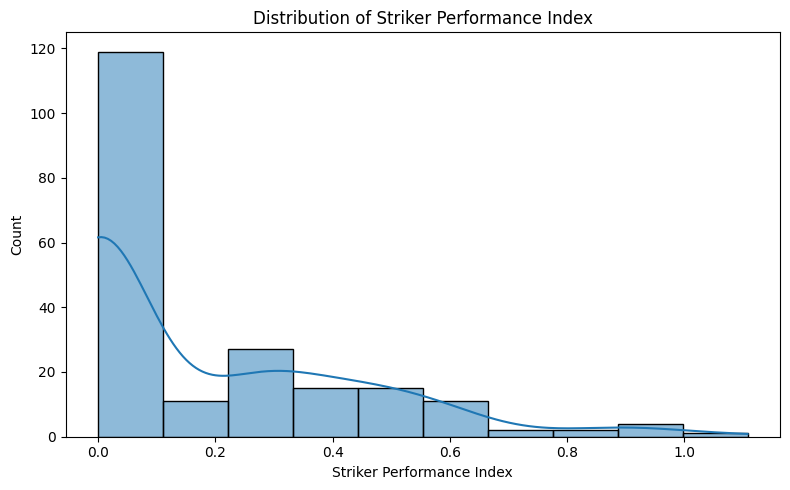

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df_out["Striker Performance Index"], kde=True)
plt.title("Distribution of Striker Performance Index")
plt.xlabel("Striker Performance Index")
plt.tight_layout()
plt.savefig("/content/eda_1_striker_performance_distribution.png", dpi=300)
plt.show()


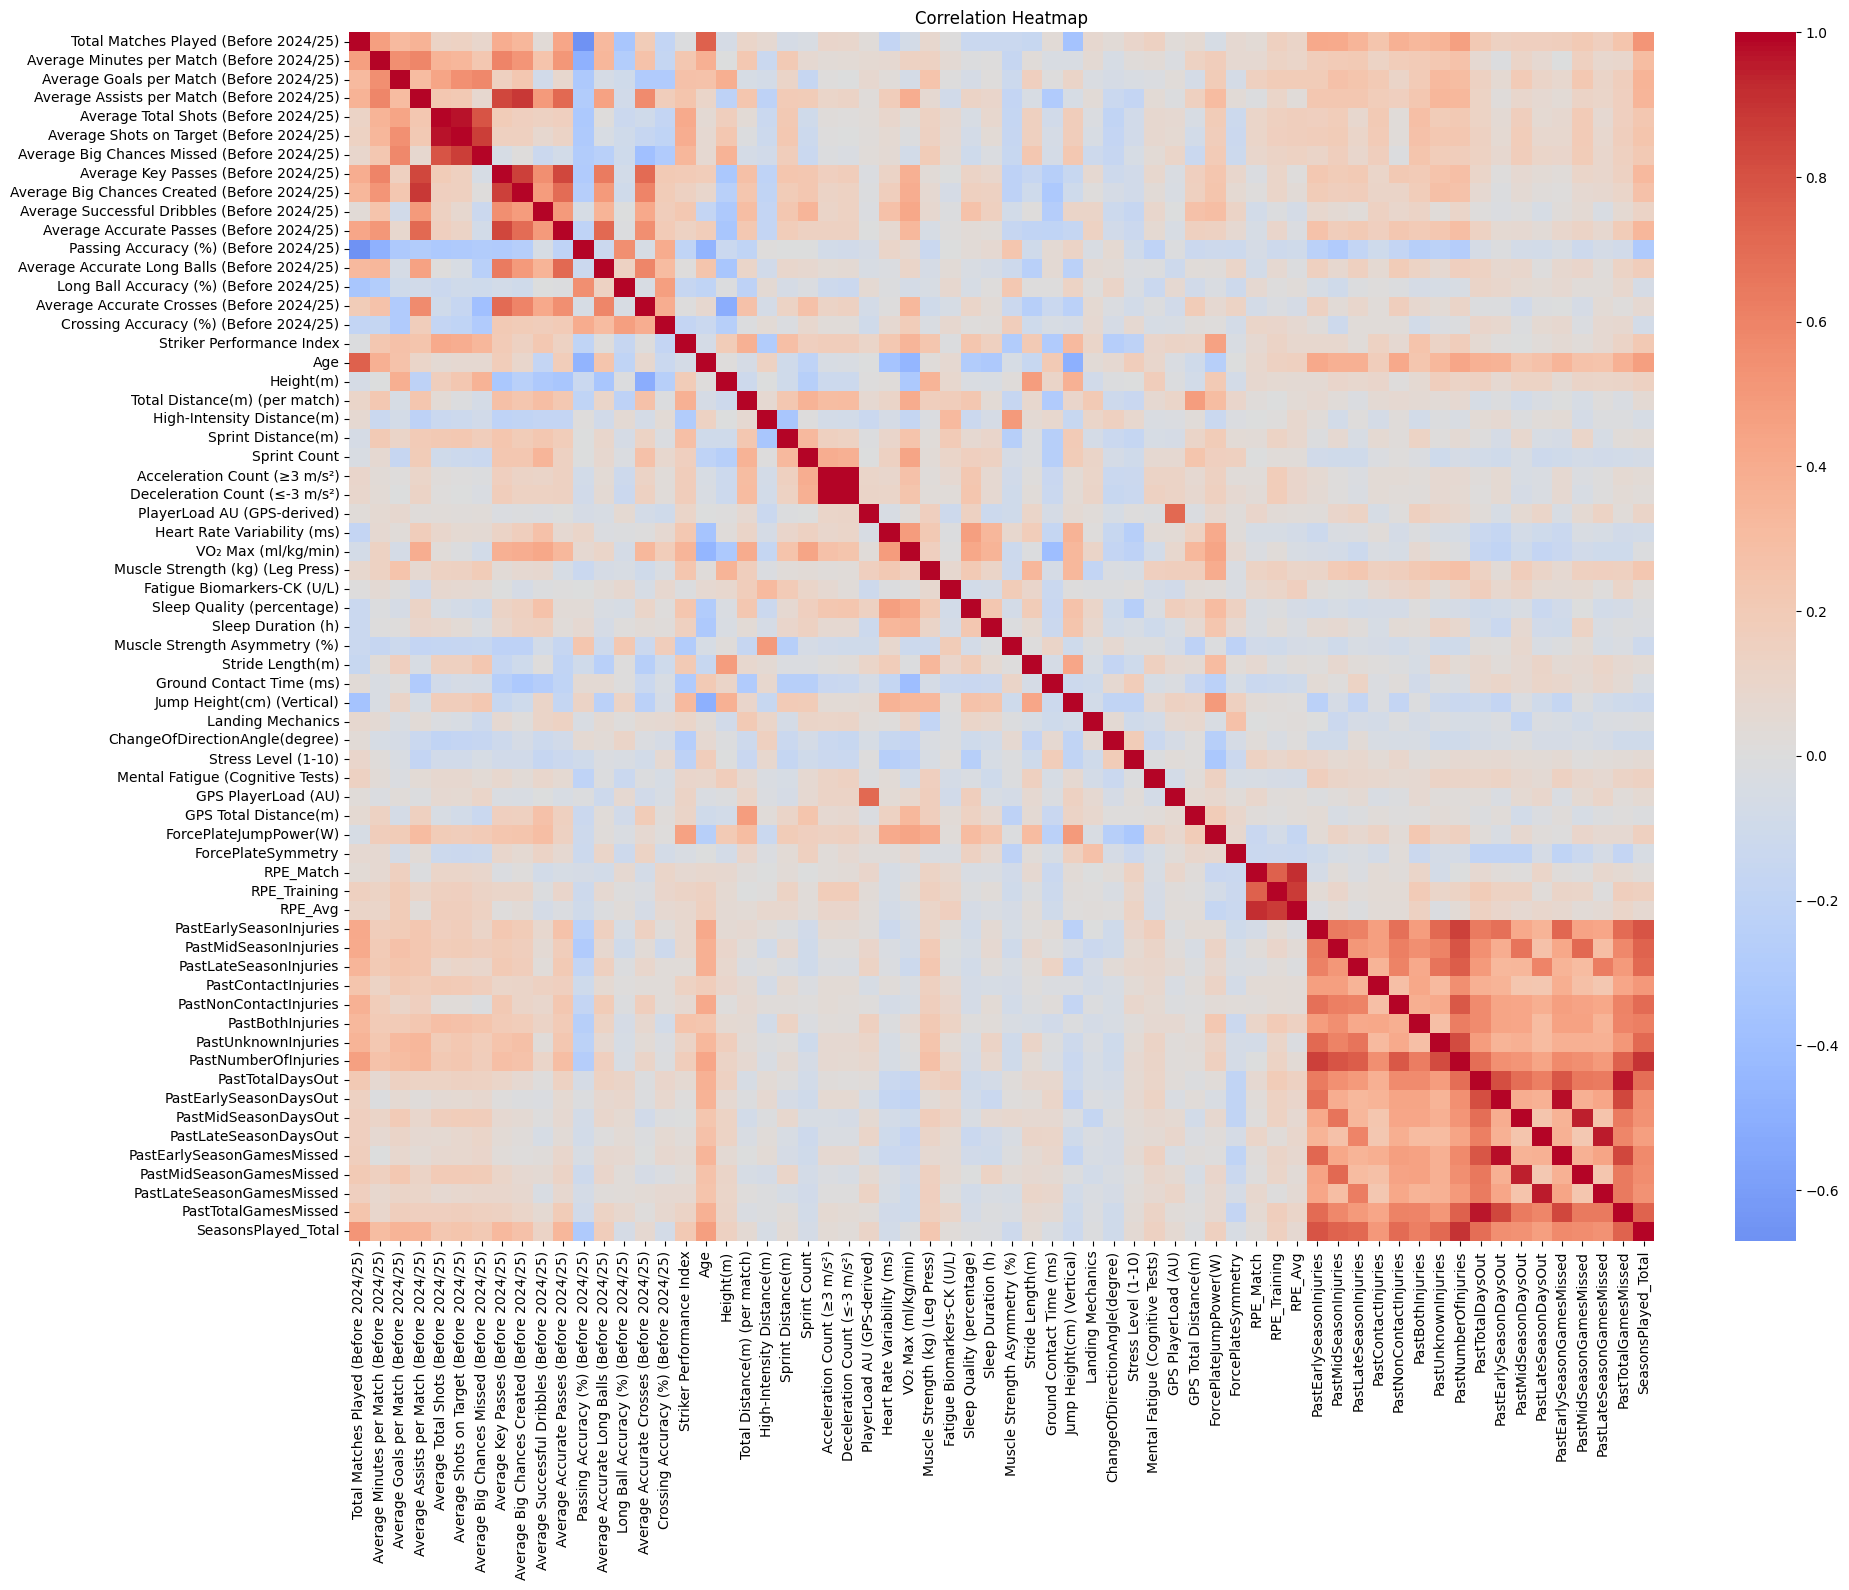

In [ ]:
plt.figure(figsize=(20,16))
sns.heatmap(df_out.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("/content/eda_2_correlation_heatmap.png", dpi=300)
plt.show()



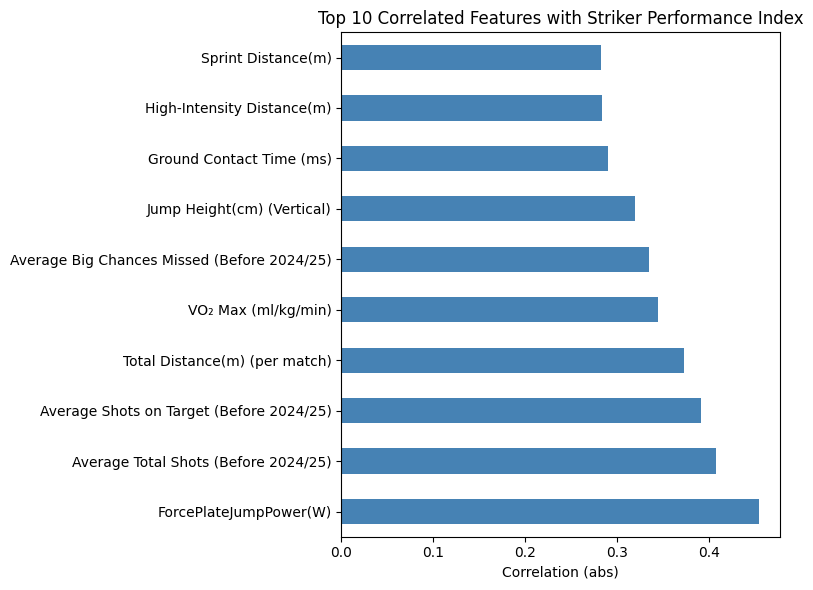

In [ ]:
corr_target = df_out.corr()["Striker Performance Index"].abs().sort_values(ascending=False)

plt.figure(figsize=(8,6))
corr_target[1:11].plot(kind='barh', color='steelblue')
plt.title("Top 10 Correlated Features with Striker Performance Index")
plt.xlabel("Correlation (abs)")
plt.tight_layout()
plt.savefig("/content/eda_3_top10_correlations.png", dpi=300)
plt.show()


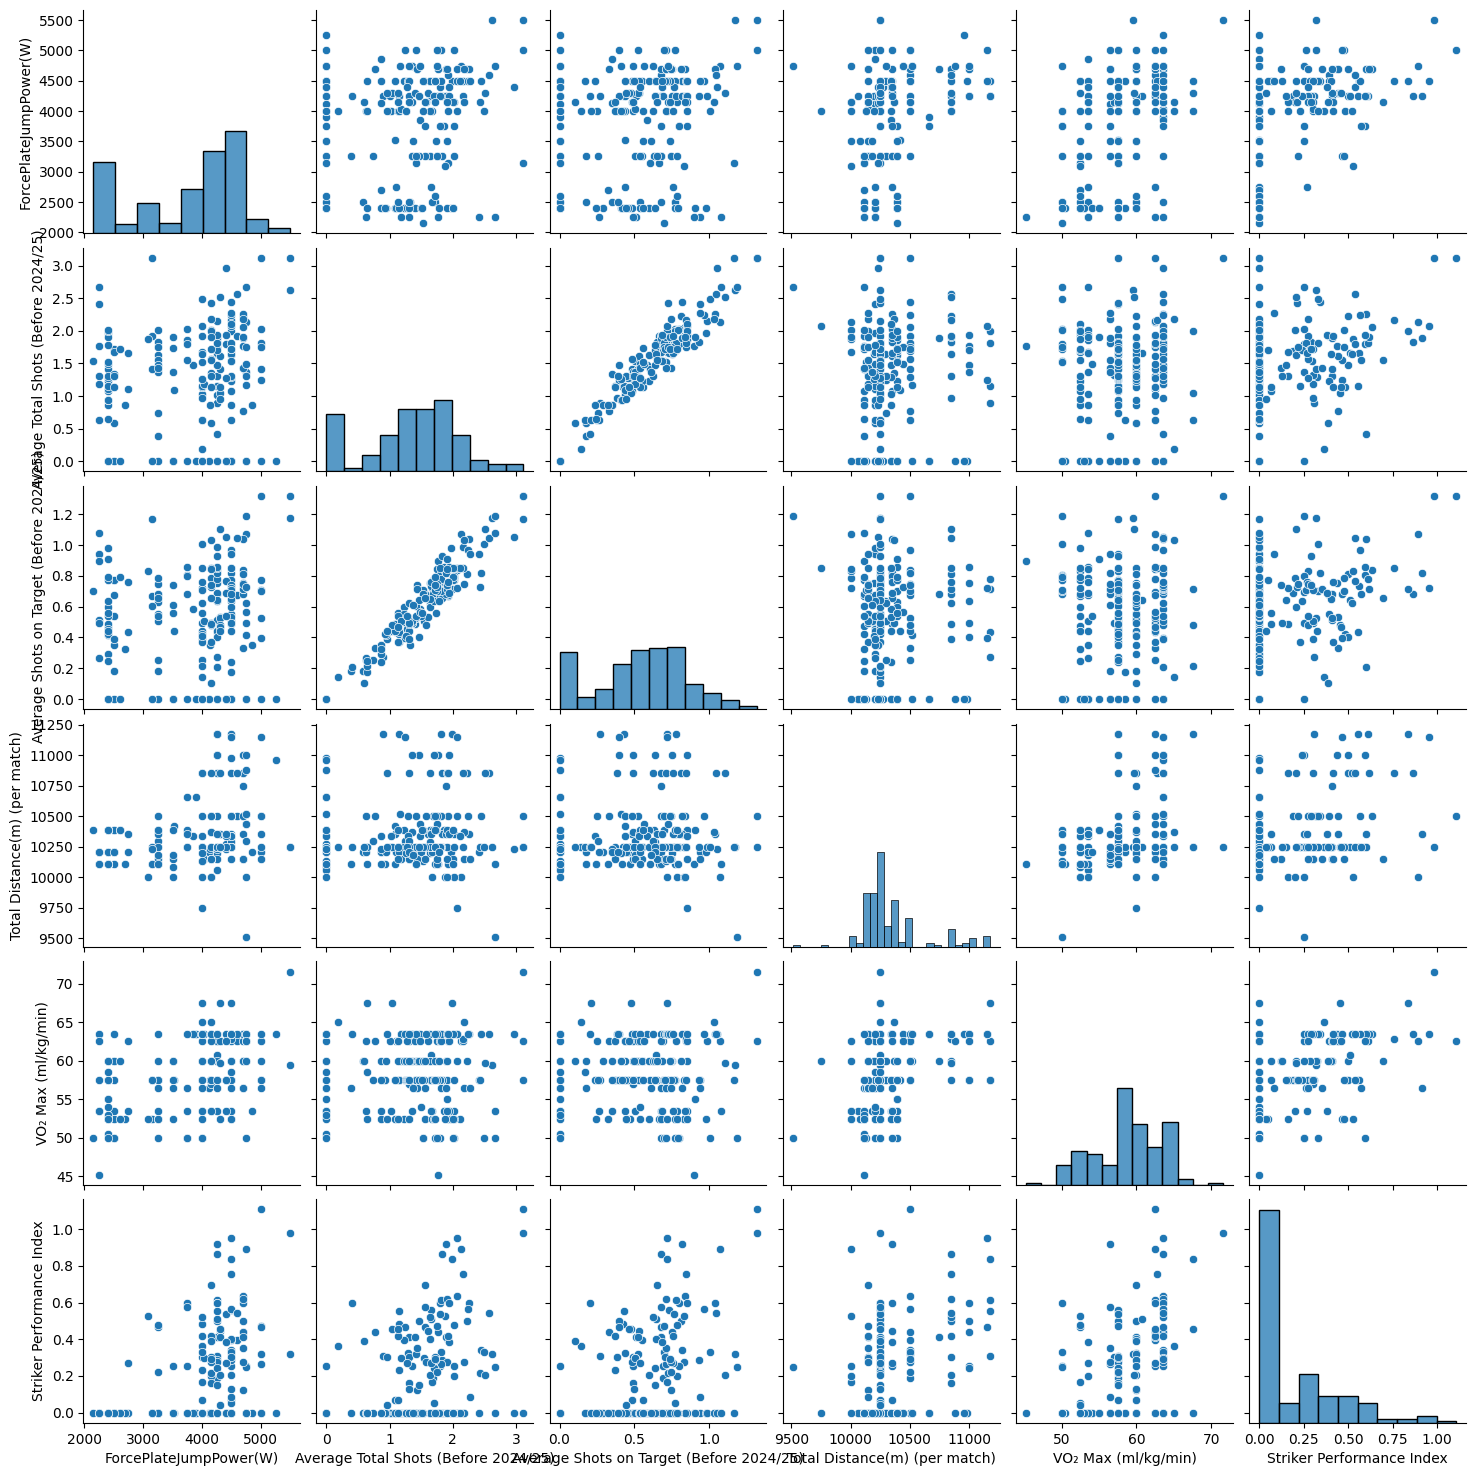

In [ ]:
top5 = corr_target.index[1:6]  # skip the target

sns.pairplot(df_out[top5.tolist() + ["Striker Performance Index"]])
plt.savefig("/content/eda_4_pairplot_top5.png", dpi=300)
plt.show()


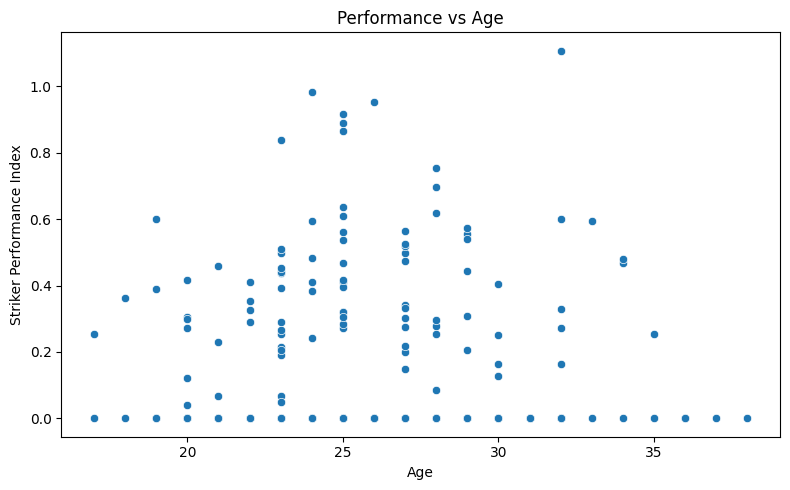

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_out, x="Age", y="Striker Performance Index")
plt.title("Performance vs Age")
plt.tight_layout()
plt.savefig("/content/eda_5_age_vs_performance.png", dpi=300)
plt.show()


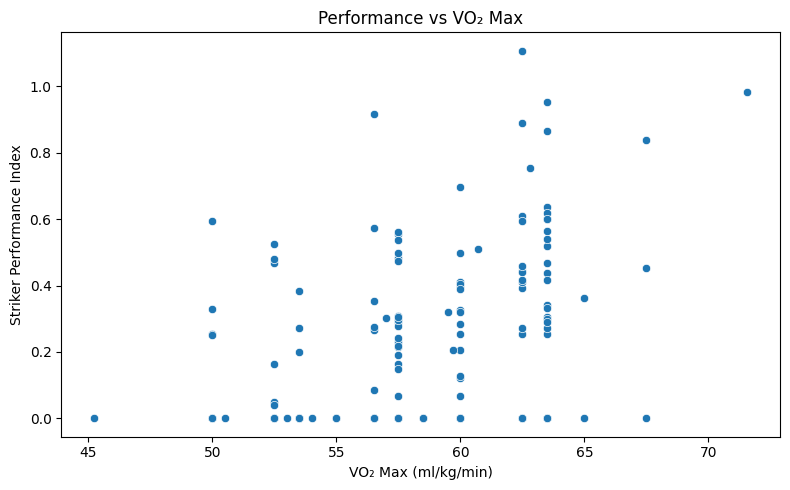

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_out, x="VO₂ Max (ml/kg/min)", y="Striker Performance Index")
plt.title("Performance vs VO₂ Max")
plt.tight_layout()
plt.savefig("/content/eda_6_vo2_vs_performance.png", dpi=300)
plt.show()


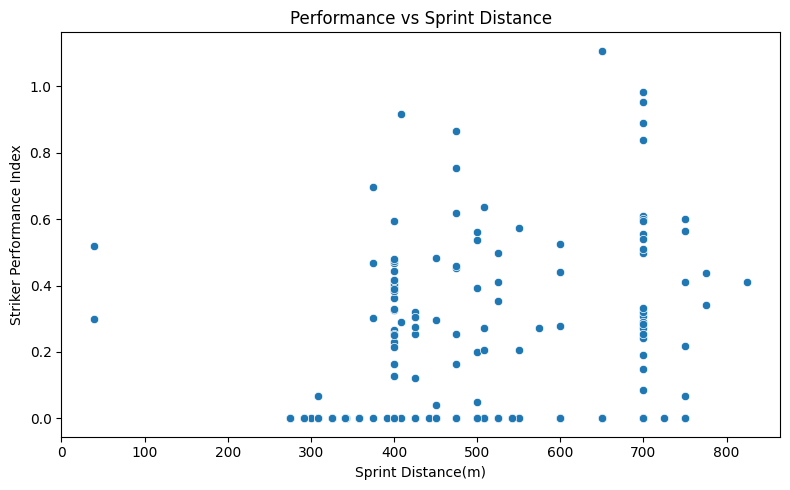

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_out, x="Sprint Distance(m)", y="Striker Performance Index")
plt.title("Performance vs Sprint Distance")
plt.tight_layout()
plt.savefig("/content/eda_7_sprint_distance_vs_performance.png", dpi=300)
plt.show()


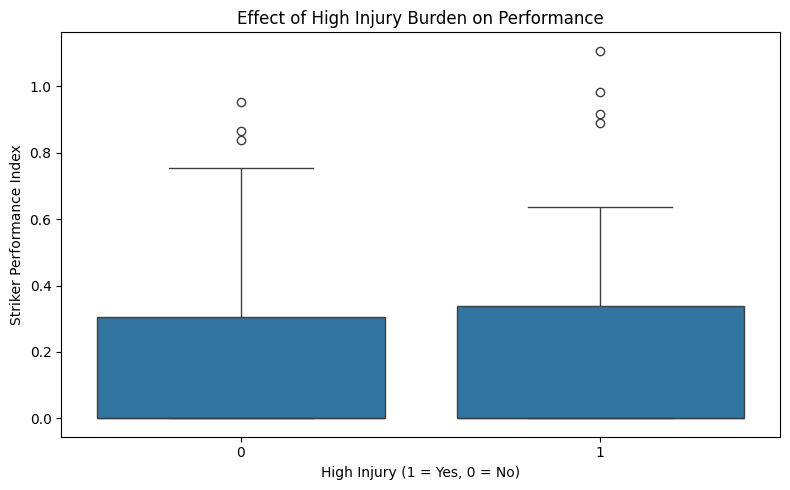

In [ ]:
df_out["HighInjury"] = (df_out["PastTotalDaysOut"] > df_out["PastTotalDaysOut"].median()).astype(int)

plt.figure(figsize=(8,5))
sns.boxplot(data=df_out, x="HighInjury", y="Striker Performance Index")
plt.title("Effect of High Injury Burden on Performance")
plt.xlabel("High Injury (1 = Yes, 0 = No)")
plt.tight_layout()
plt.savefig("/content/eda_8_injury_vs_performance.png", dpi=300)
plt.show()


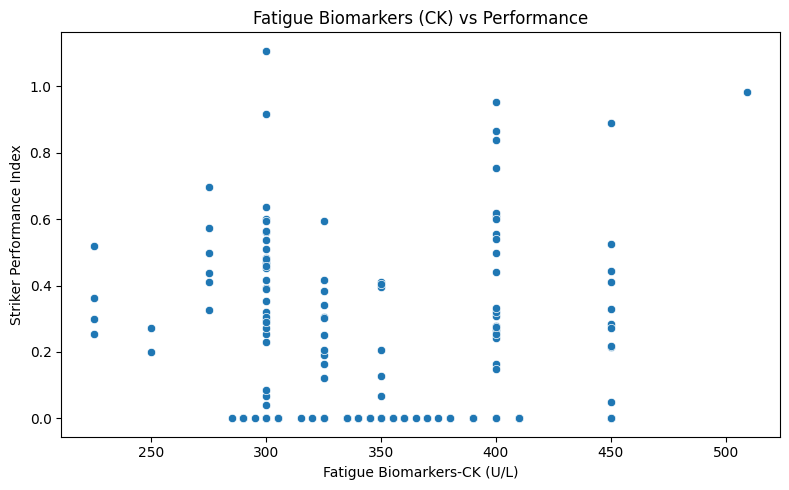

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_out, x="Fatigue Biomarkers-CK (U/L)", y="Striker Performance Index")
plt.title("Fatigue Biomarkers (CK) vs Performance")
plt.tight_layout()
plt.savefig("/content/eda_9_ck_vs_performance.png", dpi=300)
plt.show()


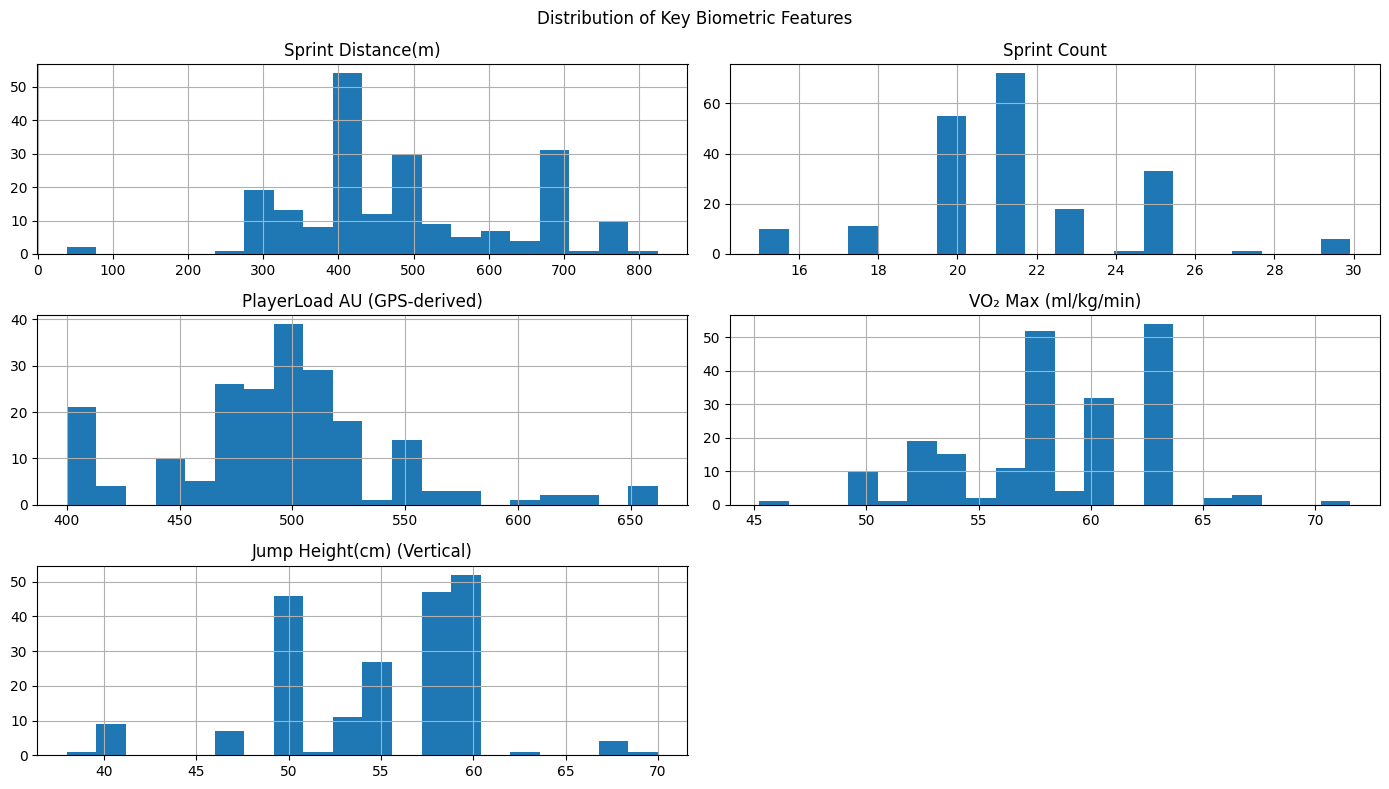

In [ ]:
key_bio = [
    "Sprint Distance(m)",
    "Sprint Count",
    "PlayerLoad AU (GPS-derived)",
    "VO₂ Max (ml/kg/min)",
    "Jump Height(cm) (Vertical)"
]

df_out[key_bio].hist(figsize=(14,8), bins=20)
plt.suptitle("Distribution of Key Biometric Features")
plt.tight_layout()
plt.savefig("/content/eda_10_key_biometric_distributions.png", dpi=300)
plt.show()


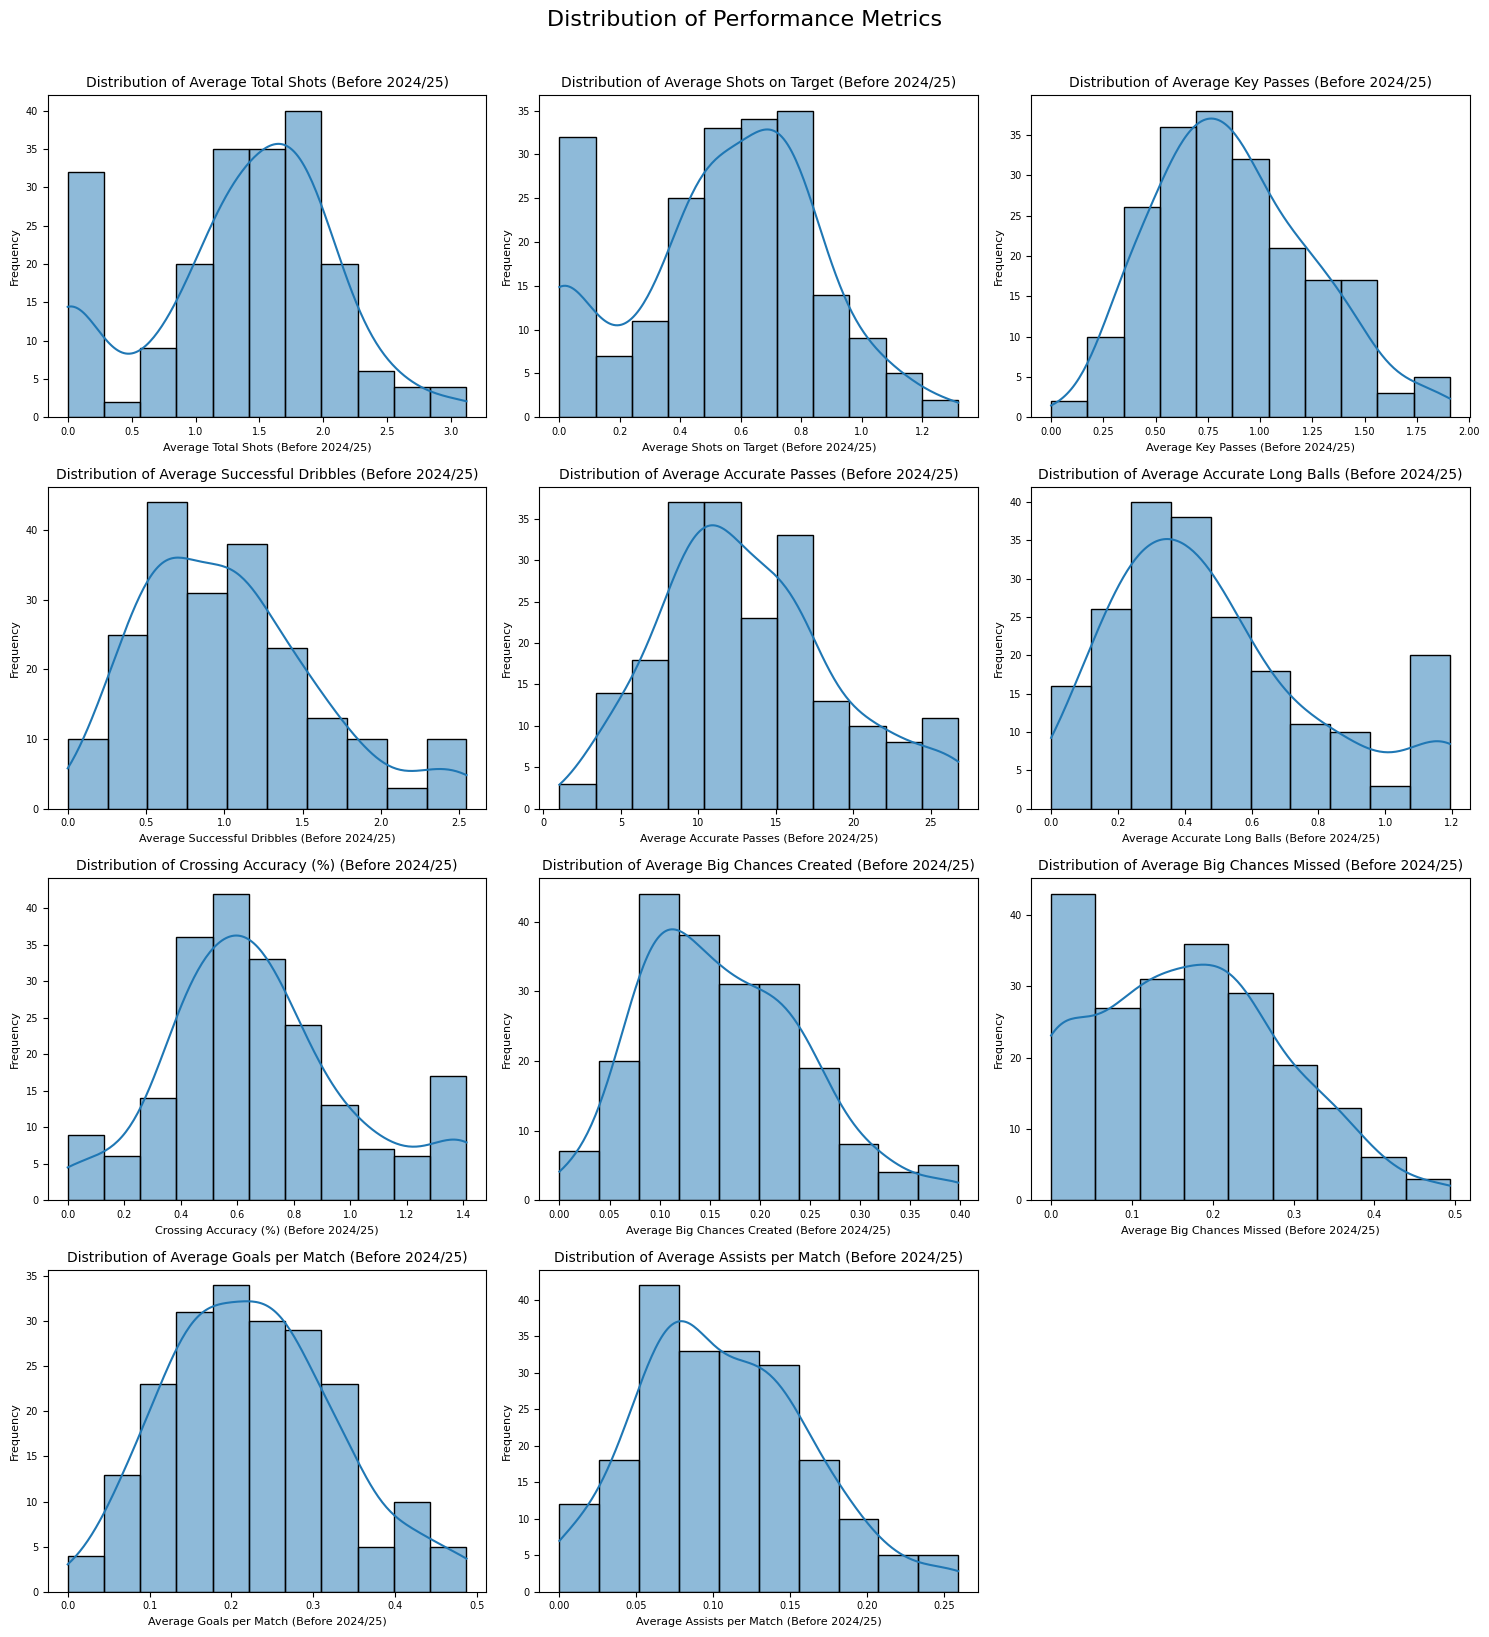

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

performance_metrics_to_plot = [
    "Average Total Shots (Before 2024/25)",
    "Average Shots on Target (Before 2024/25)",
    "Average Key Passes (Before 2024/25)",
    "Average Successful Dribbles (Before 2024/25)",
    "Average Accurate Passes (Before 2024/25)",
    "Average Accurate Long Balls (Before 2024/25)",
    "Crossing Accuracy (%) (Before 2024/25)",
    "Average Big Chances Created (Before 2024/25)",
    "Average Big Chances Missed (Before 2024/25)",
    "Average Goals per Match (Before 2024/25)",
    "Average Assists per Match (Before 2024/25)"
]

# Calculate number of rows and columns for the grid
num_plots = len(performance_metrics_to_plot)
num_cols = 3  # You can adjust this for desired layout
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(num_cols * 5, num_rows * 4))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(performance_metrics_to_plot):
    sns.histplot(df_out[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}', fontsize=10)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel('Frequency', fontsize=8)
    axes[i].tick_params(axis='x', labelsize=7)
    axes[i].tick_params(axis='y', labelsize=7)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution of Performance Metrics', fontsize=16, y=1.02) # Add a super title
plt.tight_layout(rect=[0, 0, 1, 1.01]) # Adjust layout to prevent overlapping titles/labels
plt.savefig("/content/all_performance_metrics_distributions.png", dpi=300)
plt.show()


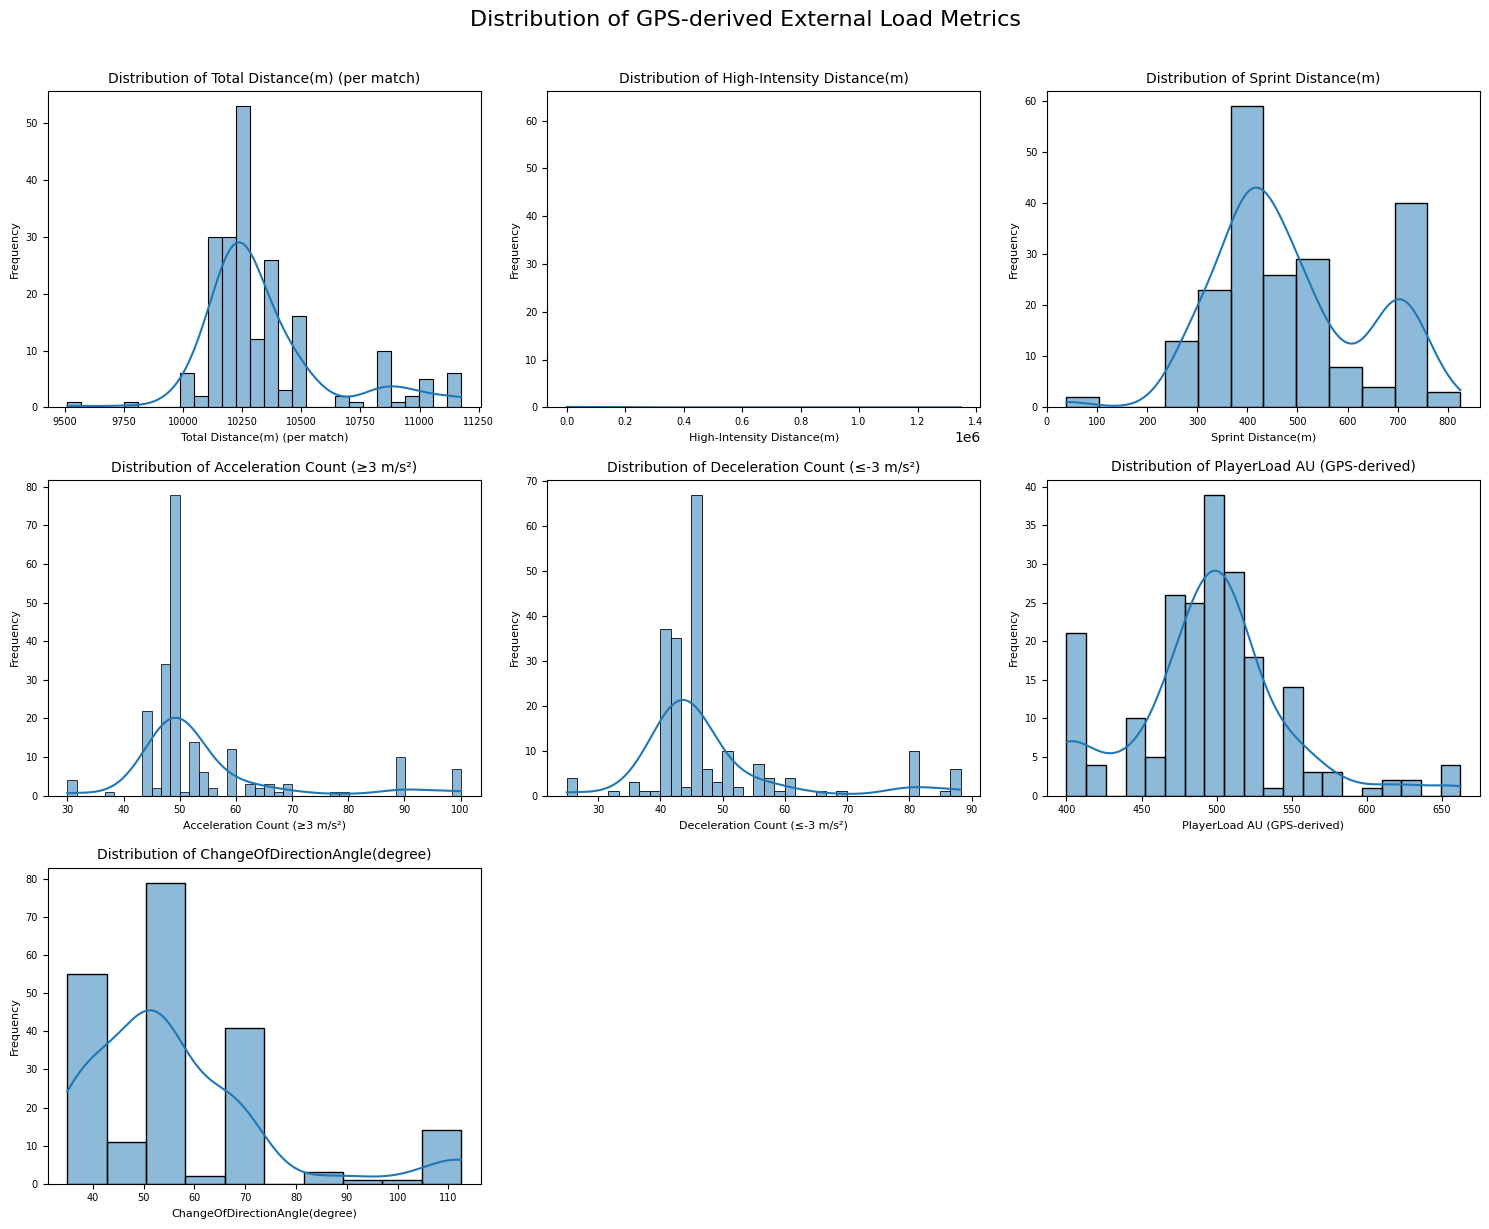

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Define the list of GPS-derived external load metrics to plot
gps_metrics_to_plot = [
    "Total Distance(m) (per match)",
    "High-Intensity Distance(m)",
    "Sprint Distance(m)",
    "Acceleration Count (≥3 m/s²)",
    "Deceleration Count (≤-3 m/s²)",
    "PlayerLoad AU (GPS-derived)",
    "ChangeOfDirectionAngle(degree)"
]

# Calculate number of rows and columns for the grid
num_plots = len(gps_metrics_to_plot)
num_cols = 3  # You can adjust this for desired layout
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(num_cols * 5, num_rows * 4))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(gps_metrics_to_plot):
    sns.histplot(df_out[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}', fontsize=10)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel('Frequency', fontsize=8)
    axes[i].tick_params(axis='x', labelsize=7)
    axes[i].tick_params(axis='y', labelsize=7)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution of GPS-derived External Load Metrics', fontsize=16, y=1.02) # Add a super title
plt.tight_layout(rect=[0, 0, 1, 1.01]) # Adjust layout to prevent overlapping titles/labels
plt.savefig("/content/gps_metrics_distributions.png", dpi=300)
plt.show()

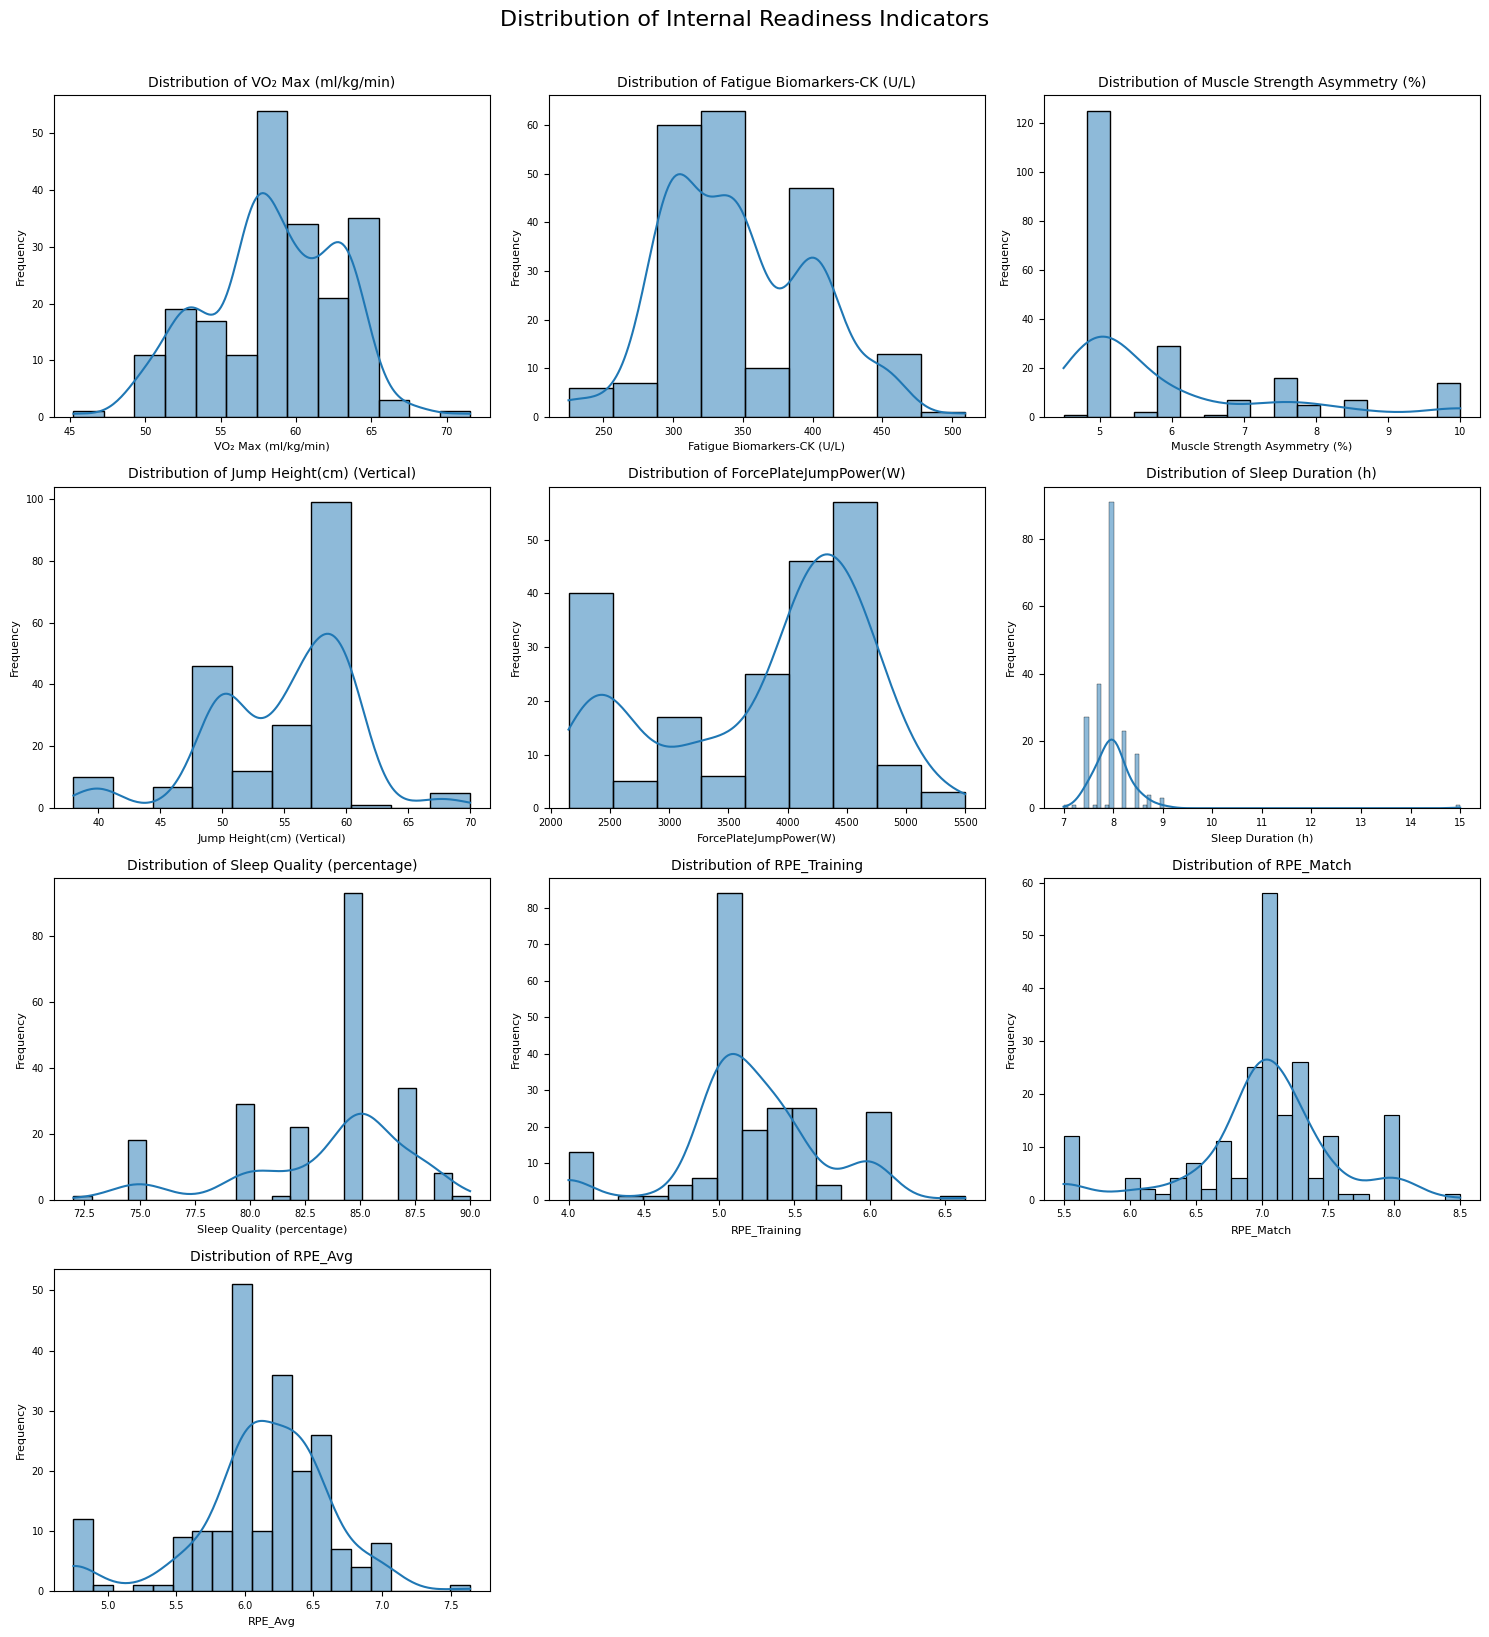

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Define the list of internal readiness indicators to plot
readiness_metrics_to_plot = [
    "VO₂ Max (ml/kg/min)",
    "Fatigue Biomarkers-CK (U/L)",
    "Muscle Strength Asymmetry (%)",
    "Jump Height(cm) (Vertical)",
    "ForcePlateJumpPower(W)",
    "Sleep Duration (h)",
    "Sleep Quality (percentage)",
    "RPE_Training",
    "RPE_Match",
    "RPE_Avg"
]

# Calculate number of rows and columns for the grid
num_plots = len(readiness_metrics_to_plot)
num_cols = 3  # You can adjust this for desired layout
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(num_cols * 5, num_rows * 4))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(readiness_metrics_to_plot):
    sns.histplot(df_out[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}', fontsize=10)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel('Frequency', fontsize=8)
    axes[i].tick_params(axis='x', labelsize=7)
    axes[i].tick_params(axis='y', labelsize=7)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution of Internal Readiness Indicators', fontsize=16, y=1.02) # Add a super title
plt.tight_layout(rect=[0, 0, 1, 1.01]) # Adjust layout to prevent overlapping titles/labels
plt.savefig("/content/readiness_metrics_distributions.png", dpi=300)
plt.show()

In [ ]:
import json
import joblib

TARGET_COL = "Striker Performance Index"

y = df_out[TARGET_COL]
X = df_out.drop(columns=[TARGET_COL])

# -------------------------------------------------------
# 2. SAVE FULL FEATURE LIST (required by GUI)
# -------------------------------------------------------
full_features = list(X.columns)
with open("striker_all_features.json", "w", encoding="utf-8") as f:
    json.dump(full_features, f)

print("Saved striker_all_features.json")


# -------------------------------------------------------
# 3. SAVE **ELITE STRIKER MEANS** (Option C)
# -------------------------------------------------------
threshold = y.quantile(0.75)    # top 25% strikers
elite_mask = y >= threshold
X_elite = X[elite_mask]

print("Total strikers:", len(X))
print("Elite strikers used for means:", len(X_elite))

elite_means = X_elite.mean(numeric_only=True).to_dict()

with open("striker_feature_means.json", "w", encoding="utf-8") as f:
    json.dump({k: float(v) for k, v in elite_means.items()}, f)

print("✅ Saved striker_feature_means.json using ELITE striker template.")



from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


Saved striker_all_features.json
Total strikers: 207
Elite strikers used for means: 52
✅ Saved striker_feature_means.json using ELITE striker template.


In [ ]:
df_out.to_csv('/content/df_out.csv', index=False)
print("df_out.csv saved to /content/")

df_out.csv saved to /content/


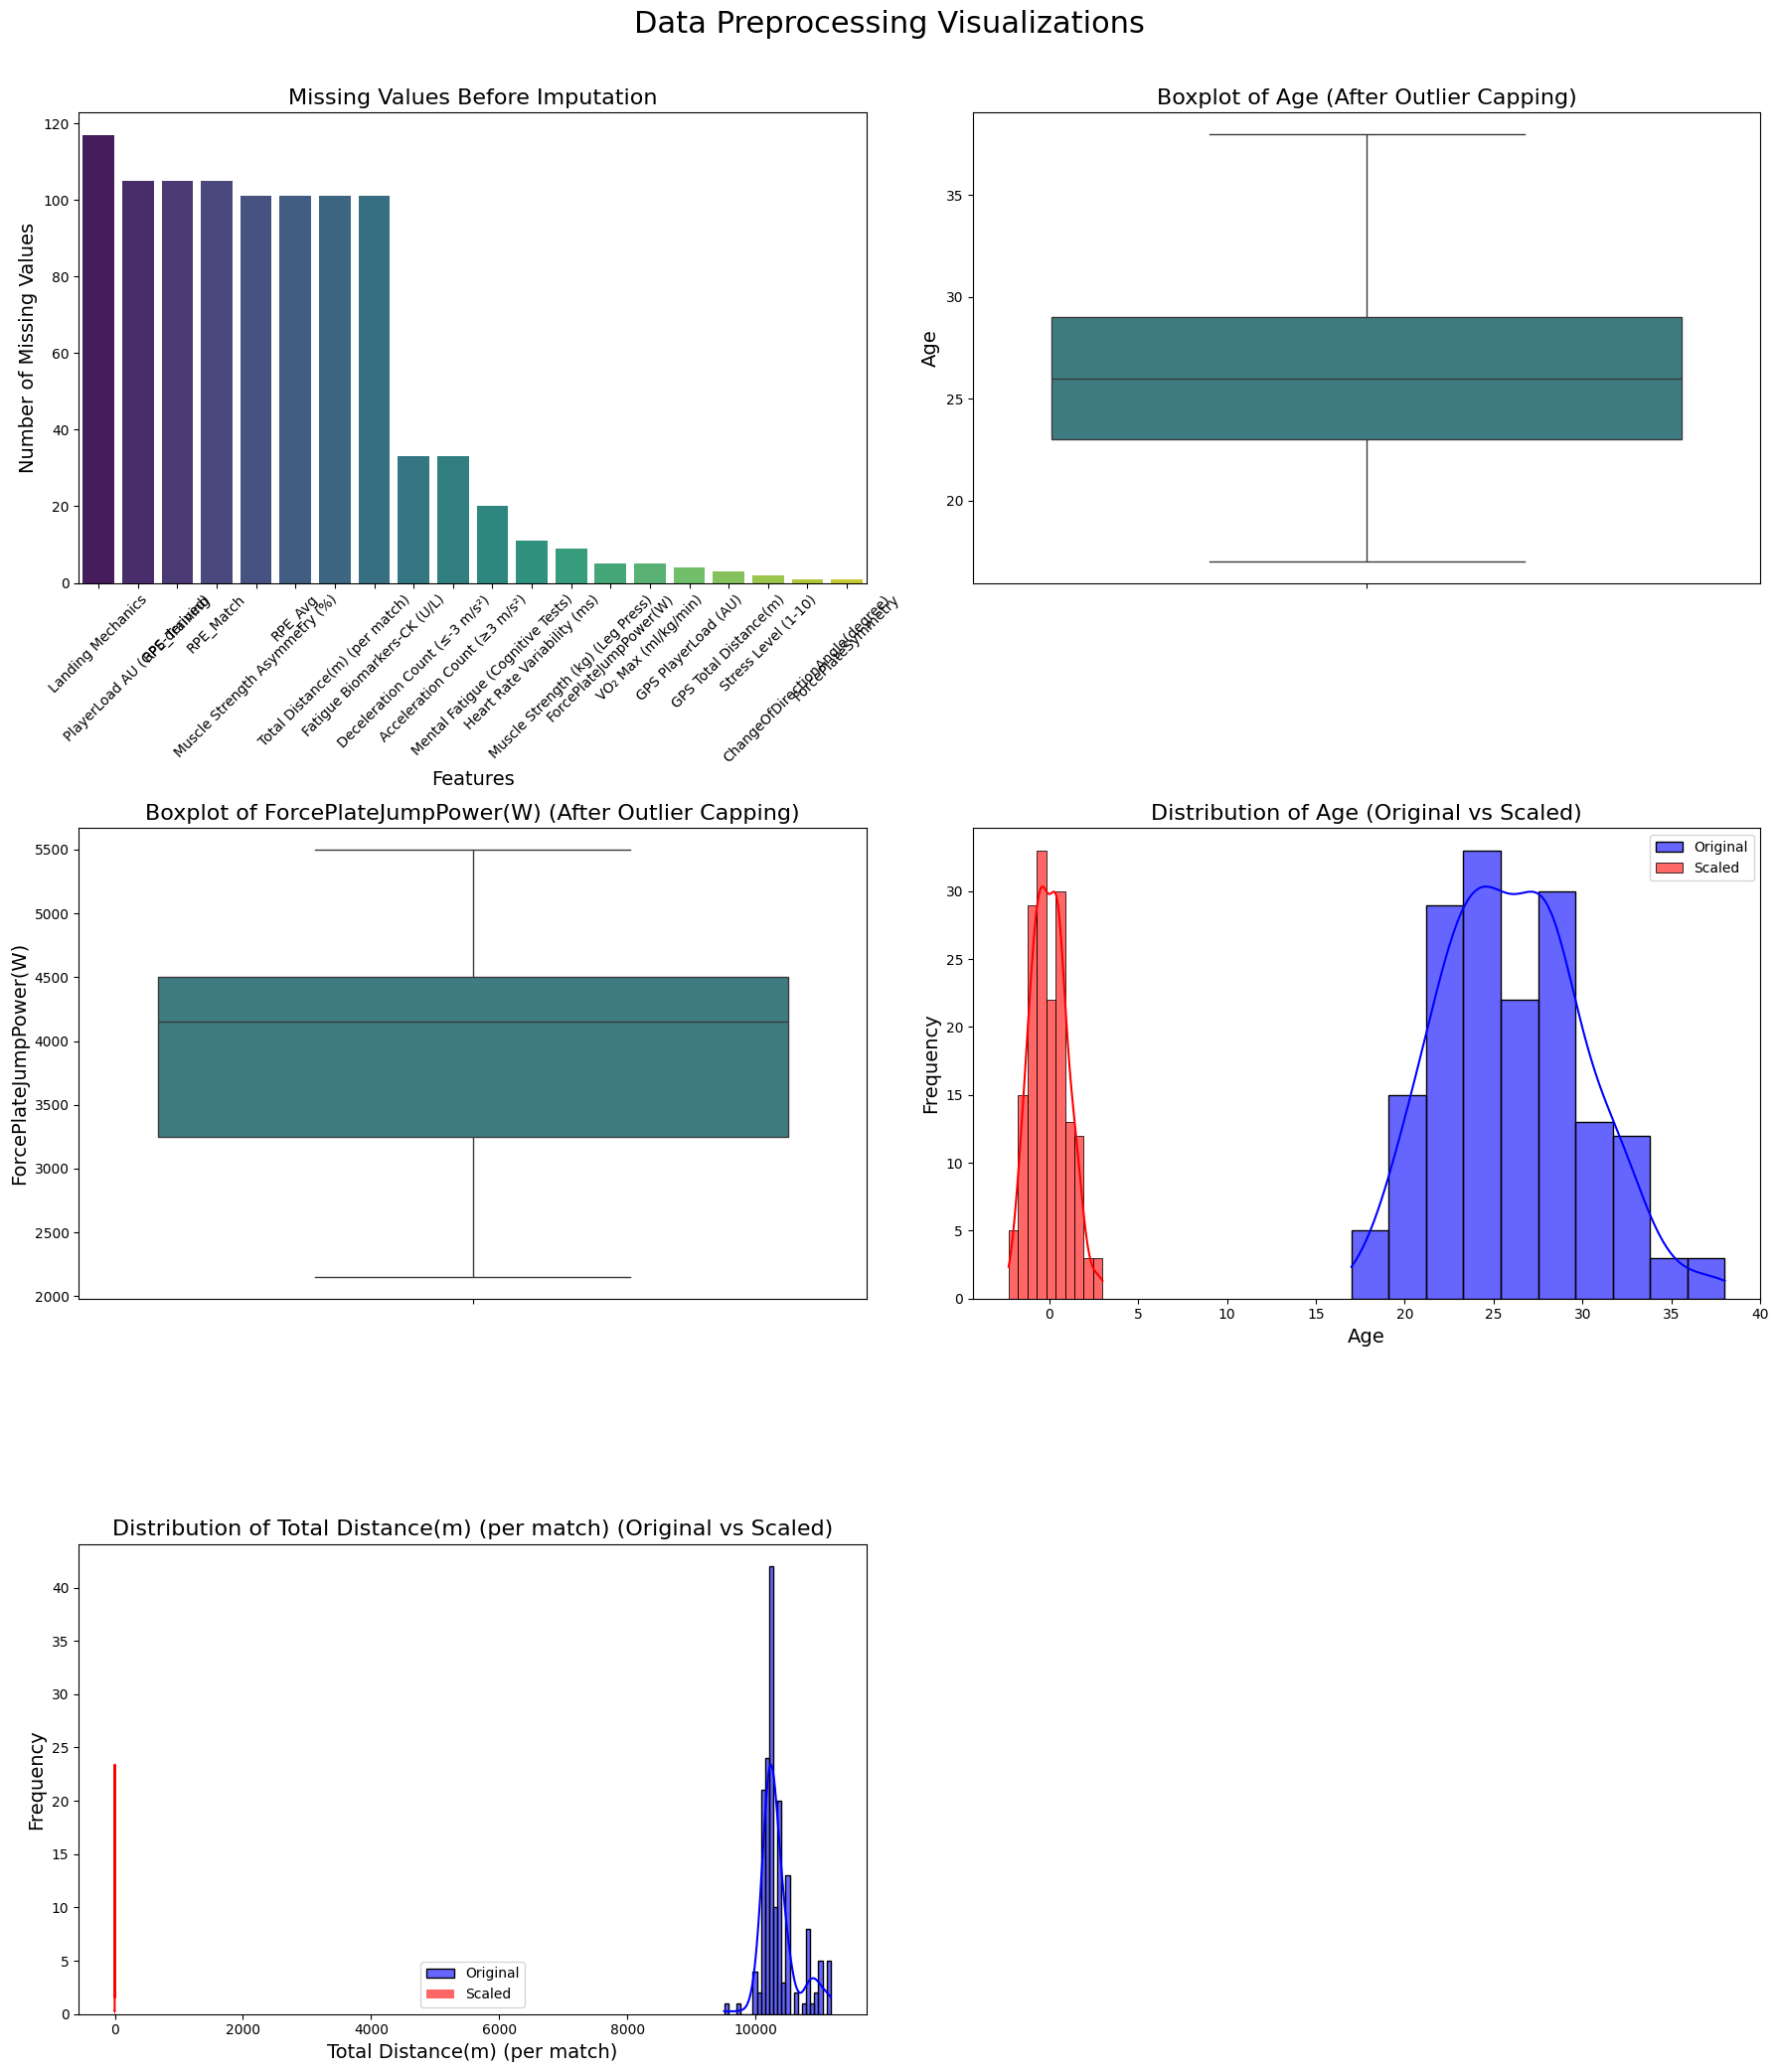

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Assume df is the DataFrame before imputation (from previous steps where NaNs were present)
# Assume df_out is the DataFrame after imputation and outlier capping
# Assume X_train and X_train_scaled are from the train-test split and scaling

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 20)) # Adjust figsize for better visibility
axes = axes.flatten() # Flatten for easy iteration

# --- 1. Missing Values Chart (from the 'df' state before imputation) ---
# The 'df' variable at this point in the notebook's execution history contains NaNs before imputation.
current_df_state_for_missing = df

missing_data = current_df_state_for_missing.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

if not missing_data.empty:
    # Use the first subplot for missing data
    sns.barplot(x=missing_data.index, y=missing_data.values, ax=axes[0], palette='viridis')
    axes[0].set_title('Missing Values Before Imputation', fontsize=16)
    axes[0].set_xlabel('Features', fontsize=14)
    axes[0].set_ylabel('Number of Missing Values', fontsize=14)
    axes[0].tick_params(axis='x', rotation=45, labelsize=10)
    axes[0].tick_params(axis='y', labelsize=10)
else:
    axes[0].text(0.5, 0.5, 'No missing values found in original df (before imputation step).',
                 horizontalalignment='center', verticalalignment='center',
                 transform=axes[0].transAxes, fontsize=14)
    axes[0].set_title('Missing Values Chart', fontsize=16)
    axes[0].set_xticks([]) # Hide x-axis ticks if no bars
    axes[0].set_yticks([]) # Hide y-axis ticks if no bars


# --- 2. Boxplots for key numerical features (from df_out after capping) ---
boxplot_features = [
    'Age',
    'ForcePlateJumpPower(W)'
]

for i, col in enumerate(boxplot_features):
    if col in df_out.columns:
        sns.boxplot(y=df_out[col], ax=axes[i+1], palette='crest')
        axes[i+1].set_title(f'Boxplot of {col} (After Outlier Capping)', fontsize=16)
        axes[i+1].set_ylabel(col, fontsize=14)
        axes[i+1].tick_params(axis='y', labelsize=10)
    else:
        axes[i+1].text(0.5, 0.5, f'"{col}" not found in df_out.',
                     horizontalalignment='center', verticalalignment='center',
                     transform=axes[i+1].transAxes, fontsize=14)
        axes[i+1].set_title(f'Boxplot for {col}', fontsize=16)
        axes[i+1].set_xticks([])
        axes[i+1].set_yticks([])

# --- 3. Scaling Plots (before vs after scaling for a couple of features) ---
# Create a DataFrame from the scaled training data for easier plotting with column names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

scaling_features = [
    'Age',
    'Total Distance(m) (per match)'
]

for i, col in enumerate(scaling_features):
    if col in X_train.columns and col in X_train_scaled_df.columns:
        sns.histplot(X_train[col], kde=True, ax=axes[i+3], color='blue', label='Original', alpha=0.6)
        sns.histplot(X_train_scaled_df[col], kde=True, ax=axes[i+3], color='red', label='Scaled', alpha=0.6)
        axes[i+3].set_title(f'Distribution of {col} (Original vs Scaled)', fontsize=16)
        axes[i+3].set_xlabel(col, fontsize=14)
        axes[i+3].set_ylabel('Frequency', fontsize=14)
        axes[i+3].legend(fontsize=10)
        axes[i+3].tick_params(axis='x', labelsize=10)
        axes[i+3].tick_params(axis='y', labelsize=10)
    else:
        axes[i+3].text(0.5, 0.5, f'"{col}" not found for scaling plot.',
                     horizontalalignment='center', verticalalignment='center',
                     transform=axes[i+3].transAxes, fontsize=14)
        axes[i+3].set_title(f'Scaling Plot for {col}', fontsize=16)
        axes[i+3].set_xticks([])
        axes[i+3].set_yticks([])

# Hide any unused subplots (if nrows*ncols > number of plots)
for j in range(1 + len(boxplot_features) + len(scaling_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Data Preprocessing Visualizations', fontsize=22, y=1.04) # Main title for the entire figure
plt.tight_layout(rect=[0, 0, 1, 1.03]) # Adjust layout to prevent overlapping titles/labels
plt.savefig("/content/data_preprocessing_visualizations.png", dpi=300)
plt.show()

In [ ]:
df_out.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 65 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Total Matches Played (Before 2024/25)         207 non-null    int64  
 1   Average Minutes per Match (Before 2024/25)    207 non-null    float64
 2   Average Goals per Match (Before 2024/25)      207 non-null    float64
 3   Average Assists per Match (Before 2024/25)    207 non-null    float64
 4   Average Total Shots (Before 2024/25)          207 non-null    float64
 5   Average Shots on Target (Before 2024/25)      207 non-null    float64
 6   Average Big Chances Missed (Before 2024/25)   207 non-null    float64
 7   Average Key Passes (Before 2024/25)           207 non-null    float64
 8   Average Big Chances Created (Before 2024/25)  207 non-null    float64
 9   Average Successful Dribbles (Before 2024/25)  207 non-null    flo

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(model, X_test, y_test, name="Model"):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    print(f"\n{name} Results:")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
rf.fit(X_train, y_train)

evaluate(rf, X_test, y_test, "Random Forest Regressor")



Random Forest Regressor Results:
MAE  : 0.0912
RMSE : 0.1318
R²   : 0.6007


In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)

evaluate(xgb, X_test, y_test, "XGBoost Regressor")



XGBoost Regressor Results:
MAE  : 0.1063
RMSE : 0.1532
R²   : 0.4604


In [ ]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)
lgbm.fit(X_train, y_train)

evaluate(lgbm, X_test, y_test, "LightGBM Regressor")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000405 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1637
[LightGBM] [Info] Number of data points in the train set: 165, number of used features: 64
[LightGBM] [Info] Start training from score 0.187184
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [ ]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.8 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='RMSE',
    verbose=False,
    random_state=42
)
cat.fit(X_train, y_train)

evaluate(cat, X_test, y_test, "CatBoost Regressor")



CatBoost Regressor Results:
MAE  : 0.1063
RMSE : 0.1425
R²   : 0.5332


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []   # store each model's performance here

def evaluate_to_table(model, X_test, y_test, name):
    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R² Score": r2
    })


# Tree-based models (no scaling)
evaluate_to_table(rf,   X_test, y_test, "Random Forest Regressor")
evaluate_to_table(xgb,  X_test, y_test, "XGBoost Regressor")
evaluate_to_table(lgbm, X_test, y_test, "LightGBM Regressor")
evaluate_to_table(cat,  X_test, y_test, "CatBoost Regressor")


results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="RMSE")

print(results_df)


                     Model       MAE      RMSE  R² Score
0  Random Forest Regressor  0.091211  0.131814  0.600685
3       CatBoost Regressor  0.106329  0.142525  0.533151
2       LightGBM Regressor  0.117594  0.152952  0.462340
1        XGBoost Regressor  0.106277  0.153235  0.460354


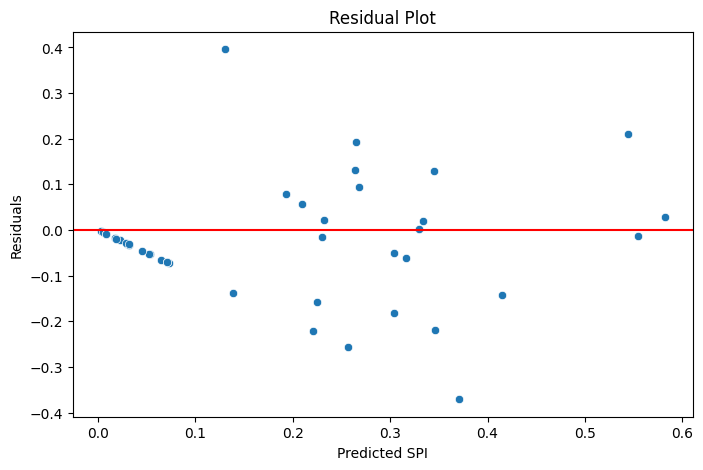

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

preds = rf.predict(X_test)
residuals = y_test - preds

plt.figure(figsize=(8,5))
sns.scatterplot(x=preds, y=residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted SPI")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


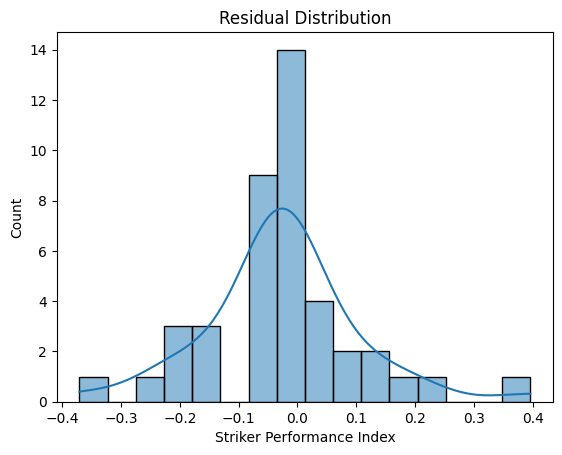

In [ ]:
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()


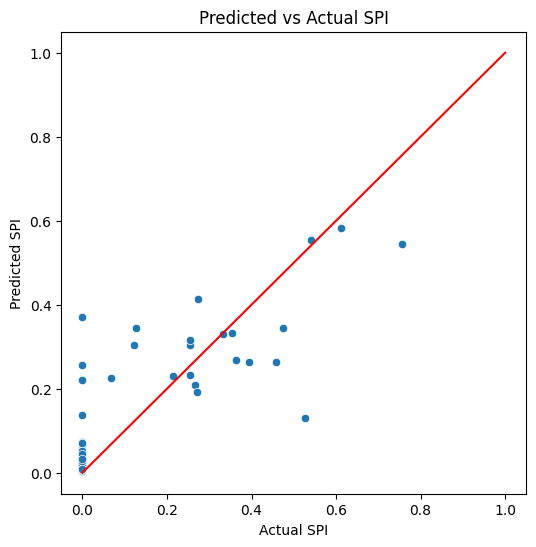

In [ ]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=preds)
plt.plot([0,1],[0,1], color='red')
plt.xlabel("Actual SPI")
plt.ylabel("Predicted SPI")
plt.title("Predicted vs Actual SPI")
plt.show()


In [ ]:
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
print(feat_imp.head(55))


ForcePlateJumpPower(W)                          0.080419
RPE_Avg                                         0.076554
Average Total Shots (Before 2024/25)            0.070545
Muscle Strength Asymmetry (%)                   0.067471
Total Distance(m) (per match)                   0.061511
PlayerLoad AU (GPS-derived)                     0.053728
Passing Accuracy (%) (Before 2024/25)           0.037197
RPE_Training                                    0.036672
Average Shots on Target (Before 2024/25)        0.035355
Average Big Chances Missed (Before 2024/25)     0.031155
Fatigue Biomarkers-CK (U/L)                     0.026288
Average Goals per Match (Before 2024/25)        0.020664
VO₂ Max (ml/kg/min)                             0.017992
Acceleration Count (≥3 m/s²)                    0.017134
Deceleration Count (≤-3 m/s²)                   0.015755
GPS Total Distance(m)                           0.015716
RPE_Match                                       0.014926
Average Assists per Match (Befo

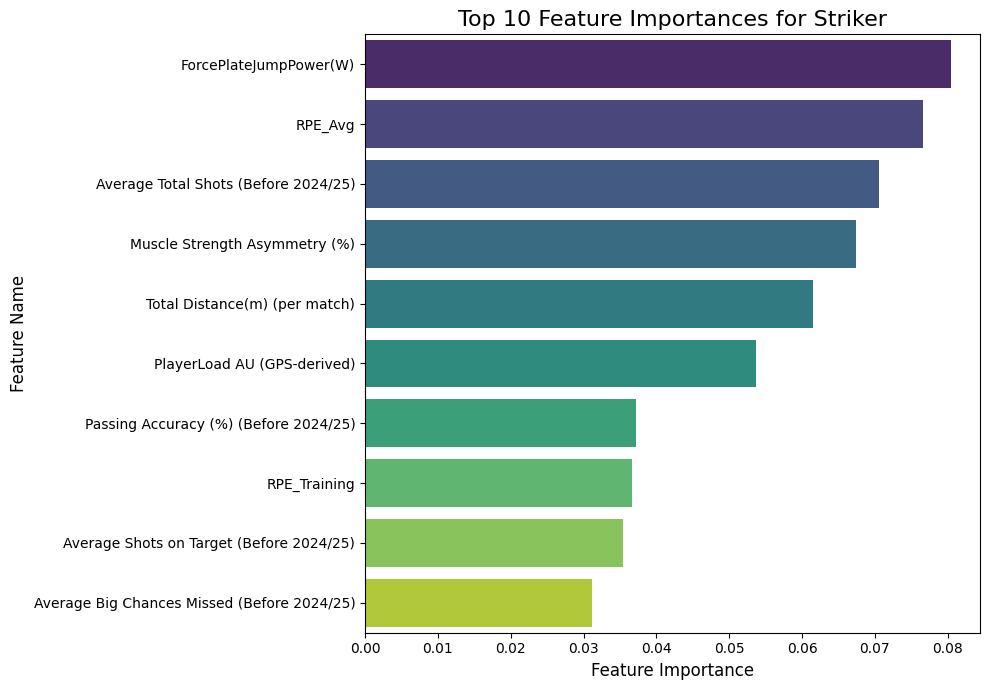

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure feat_imp is available (it was created in cell wGc7XH0ezJ7G)
# feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=feat_imp.head(10).values, y=feat_imp.head(10).index, palette='viridis')
plt.title('Top 10 Feature Importances for Striker', fontsize=16)
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.savefig('/content/rf_top10_feature_importances.png', dpi=300)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ----- X, y -----
target_col = "Striker Performance Index"

X = df_out.drop(columns=[target_col])
y = df_out[target_col]

# ----- Train / test -----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----- Evaluation helper -----
def evaluate_model(model, X_test, y_test, name="Model"):
    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)

    print(f"\n{name}")
    print("-"*40)
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf_params = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [None, 4, 6, 8, 10],
    "min_samples_split": [2, 4, 6],
    "min_samples_leaf": [1, 2, 3],
    "max_features": ["auto", "sqrt", 0.5]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=30,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best RF params:", rf_search.best_params_)
evaluate_model(rf_search.best_estimator_, X_test, y_test, "Random Forest (tuned)")


Best RF params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}

Random Forest (tuned)
----------------------------------------
MAE  : 0.1063
RMSE : 0.1373
R²   : 0.5666


In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist"  # fast on CPU
)

xgb_params = {
    "n_estimators": [200, 400, 600, 800],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "min_child_weight": [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=40,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

print("\nBest XGB params:", xgb_search.best_params_)
evaluate_model(xgb_search.best_estimator_, X_test, y_test, "XGBoost (tuned)")


KeyboardInterrupt: 

In [ ]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(random_state=42)

lgbm_params = {
    "n_estimators": [200, 400, 600, 800],
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 4, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0]
}

lgbm_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=lgbm_params,
    n_iter=40,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1
)

lgbm_search.fit(X_train, y_train)

print("\nBest LGBM params:", lgbm_search.best_params_)
evaluate_model(lgbm_search.best_estimator_, X_test, y_test, "LightGBM (tuned)")


In [ ]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    loss_function="RMSE",
    random_state=42,
    verbose=False
)

cat_params = {
    "iterations": [300, 500, 800],
    "depth": [4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7, 9]
}

cat_search = RandomizedSearchCV(
    estimator=cat,
    param_distributions=cat_params,
    n_iter=30,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1
)

cat_search.fit(X_train, y_train)

print("\nBest CatBoost params:", cat_search.best_params_)
evaluate_model(cat_search.best_estimator_, X_test, y_test, "CatBoost (tuned)")


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.preprocessing import StandardScaler

results_compare = []

def eval_store(model, Xtest, ytest, name):
    preds = model.predict(Xtest)
    mae  = mean_absolute_error(ytest, preds)
    rmse = np.sqrt(mean_squared_error(ytest, preds))
    r2   = r2_score(ytest, preds)

    results_compare.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })


# -----------------------------
# Assume X_train, X_test, y_train, y_test already exist
# If not, recreate them from df_out:
# X = df_out.drop(columns=["Striker Performance Index"])
# y = df_out["Striker Performance Index"]
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )
# -----------------------------

# ---- scaling for linear models ----
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ---------- BASELINE MODELS (refit here) ----------

rf_base = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
rf_base.fit(X_train, y_train)
eval_store(rf_base, X_test, y_test, "Random Forest (baseline)")

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_base.fit(X_train, y_train)
eval_store(xgb_base, X_test, y_test, "XGBoost (baseline)")

lgbm_base = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)
lgbm_base.fit(X_train, y_train)
eval_store(lgbm_base, X_test, y_test, "LightGBM (baseline)")

cat_base = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    verbose=False,
    random_state=42
)
cat_base.fit(X_train, y_train)
eval_store(cat_base, X_test, y_test, "CatBoost (baseline)")

lr_base = LinearRegression()
lr_base.fit(X_train_scaled, y_train)
eval_store(lr_base, X_test_scaled, y_test, "Linear Regression (baseline)")

elastic_base = ElasticNet(
    alpha=0.001,
    l1_ratio=0.5,
    random_state=42
)
elastic_base.fit(X_train_scaled, y_train)
eval_store(elastic_base, X_test_scaled, y_test, "ElasticNet (baseline)")


# ---------- TUNED MODELS (already fitted by RandomizedSearchCV) ----------

eval_store(rf_search.best_estimator_,   X_test, y_test, "Random Forest (tuned)")
eval_store(xgb_search.best_estimator_,  X_test, y_test, "XGBoost (tuned)")
eval_store(lgbm_search.best_estimator_, X_test, y_test, "LightGBM (tuned)")
eval_store(cat_search.best_estimator_,  X_test, y_test, "CatBoost (tuned)")


# ---------- RESULT TABLE ----------

df_compare = pd.DataFrame(results_compare)
df_compare = df_compare.sort_values(by="R²", ascending=False)
print(df_compare)


In [ ]:
import shap
import matplotlib.pyplot as plt

# rf_final should be your final RF model (e.g. rf_final = rf_base)
rf_final = rf_base # Assigning the best performing Random Forest model
explainer = shap.TreeExplainer(rf_final)
shap_values = explainer.shap_values(X_train)

# -------- SHAP SUMMARY DOT PLOT --------
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train, show=False)
plt.tight_layout()
plt.savefig("shap_summary_dot.png", dpi=300, bbox_inches="tight")
plt.close()

# -------- SHAP SUMMARY BAR PLOT --------
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("shap_summary_bar.png", dpi=300, bbox_inches="tight")
plt.close()

print("Saved:")
print(" - shap_summary_dot.png")
print(" - shap_summary_bar.png")

In [ ]:
from IPython.display import Image, display

display(Image(filename="shap_summary_dot.png"))
display(Image(filename="shap_summary_bar.png"))

In [ ]:
import joblib
import json

best_striker_model = rf_base  # Corrected to use the best performing RF model
joblib.dump(best_striker_model, "striker_model.pkl")

feature_names_str = list(X.columns) # Corrected to use the features DataFrame X
with open("striker_features.json", "w") as f:
    json.dump(feature_names_str, f)


In [ ]:
model = joblib.load("striker_model.pkl")

import numpy as np
import pandas as pd

importance = model.feature_importances_
names = pd.Series(importance, index=list(X.columns))
names.sort_values(ascending=False).head(20)


In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="R²", data=df_compare, palette="viridis")
plt.title("Model Performance Comparison (R² Score)", fontsize=16)
plt.xlabel("Model", fontsize=12)
plt.ylabel("R² Score", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/content/model_r2_comparison.png", dpi=300)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="MAE", data=df_compare.sort_values(by="MAE"), palette="viridis")
plt.title("Model Performance Comparison (MAE)", fontsize=16)
plt.xlabel("Model", fontsize=12)
plt.ylabel("MAE", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/content/model_mae_comparison.png", dpi=300)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="RMSE", data=df_compare.sort_values(by="RMSE"), palette="viridis")
plt.title("Model Performance Comparison (RMSE)", fontsize=16)
plt.xlabel("Model", fontsize=12)
plt.ylabel("RMSE", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/content/model_rmse_comparison.png", dpi=300)
plt.show()

In [ ]:
from IPython.display import Image, display

# Display the previously generated R² plot
display(Image(filename="/content/model_r2_comparison.png"))

# Display the newly generated MAE and RMSE plots
display(Image(filename="/content/model_mae_comparison.png"))
display(Image(filename="/content/model_rmse_comparison.png"))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve

# Use the best performing model (RandomForestRegressor from rf_base)
model_for_lc = rf_base

# Generate learning curve data
train_sizes, train_scores, test_scores = learning_curve(
    model_for_lc, X_train, y_train, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='neg_mean_squared_error'
)

# Convert scores to positive RMSE
train_rmse = np.sqrt(-train_scores)
test_rmse = np.sqrt(-test_scores)

# Calculate mean and standard deviation for train and test scores
train_rmse_mean = np.mean(train_rmse, axis=1)
train_rmse_std = np.std(train_rmse, axis=1)
test_rmse_mean = np.mean(test_rmse, axis=1)
test_rmse_std = np.std(test_rmse, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_rmse_mean, 'o-', color="r", label="Training RMSE")
plt.fill_between(train_sizes, train_rmse_mean - train_rmse_std,
                 train_rmse_mean + train_rmse_std, alpha=0.1, color="r")
plt.plot(train_sizes, test_rmse_mean, 'o-', color="g", label="Cross-validation RMSE")
plt.fill_between(train_sizes, test_rmse_mean - test_rmse_std,
                 test_rmse_mean + test_rmse_std, alpha=0.1, color="g")

plt.title("Learning Curve (Random Forest Regressor)")
plt.xlabel("Training Examples")
plt.ylabel("RMSE")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.savefig("/content/learning_curve.png", dpi=300)
plt.show()

from IPython.display import Image, display
display(Image(filename="/content/learning_curve.png"))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(y=residuals)
plt.title('Residual Boxplot for Striker Performance Index')
plt.ylabel('Residuals')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestRegressor

# Ensure rf_base is defined. If it's not from a previous run, you might need to re-define it:
# rf_base = RandomForestRegressor(n_estimators=300, random_state=42)
# rf_base.fit(X_train, y_train) # Assuming X_train, y_train are available

# Use the best performing model (RandomForestRegressor from rf_base)
model_for_lc = rf_base

# Generate learning curve data using R² score
train_sizes, train_scores, test_scores = learning_curve(
    model_for_lc, X_train, y_train, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='r2' # Changed scoring to 'r2'
)

# R² scores do not need transformation like RMSE
train_r2_mean = np.mean(train_scores, axis=1)
train_r2_std = np.std(train_scores, axis=1)
test_r2_mean = np.mean(test_scores, axis=1)
test_r2_std = np.std(test_scores, axis=1)

# Plot the learning curve for R² score
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_r2_mean, 'o-', color="r", label="Training R² Score")
plt.fill_between(train_sizes, train_r2_mean - train_r2_std,
                 train_r2_mean + train_r2_std, alpha=0.1, color="r")
plt.plot(train_sizes, test_r2_mean, 'o-', color="g", label="Cross-validation R² Score")
plt.fill_between(train_sizes, test_r2_mean - test_r2_std,
                 test_r2_mean + test_r2_std, alpha=0.1, color="g")

plt.title("Learning Curve (Random Forest Regressor) - R² Score")
plt.xlabel("Training Examples")
plt.ylabel("R² Score") # Changed y-label to R² Score
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.savefig("/content/learning_curve_r2.png", dpi=300) # Saved with a different filename
plt.show()

from IPython.display import Image, display
display(Image(filename="/content/learning_curve_r2.png"))

In [ ]:
from sklearn.metrics import r2_score
import pandas as pd

# Assuming rf_base is the best performing model from previous steps
training_r2 = r2_score(y_train, rf_base.predict(X_train))
test_r2 = r2_score(y_test, rf_base.predict(X_test))

print(f"Random Forest Regressor (Baseline) Training R²: {training_r2:.4f}")
print(f"Random Forest Regressor (Baseline) Test R²: {test_r2:.4f}")

# Also show the comparison table for all models' test R²
print("\n--- Overall Model Test R² Comparison ---")
print(df_compare[['Model', 'R²']].sort_values(by='R²', ascending=False).to_string(index=False))